#0. ETL & Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import folium
import geopandas as gpd
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from scipy.stats import pearsonr


# Cargar el dataset principal
df_consumo_agregado = pd.read_parquet('consumo_agregado.parquet')
print("\n--- 1. Consumo Agregado ---")
df_consumo_agregado.info()
print("\nPrimeras filas del Consumo Agregado:")
df_consumo_agregado.head()


--- 1. Consumo Agregado ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963419 entries, 0 to 963418
Data columns (total 7 columns):
 #   Column                                                                             Non-Null Count   Dtype 
---  ------                                                                             --------------   ----- 
 0   Secció censal/Sección censal/Census section                                        962324 non-null  object
 1   Districte/Distrito/District                                                        962324 non-null  object
 2   Municipi/Municipio/Municipality                                                    963419 non-null  object
 3   Data/Fecha/Date                                                                    963419 non-null  object
 4   Ús/Uso/Use                                                                         963419 non-null  object
 5   Nombre de comptadors/Número de contadores/Number of meters              

,Secció censal/Sección censal/Census section,Districte/Distrito/District,Municipi/Municipio/Municipality,Data/Fecha/Date,Ús/Uso/Use,Nombre de comptadors/Número de contadores/Number of meters,Consum acumulat (L/dia)/Consumo acumulado (L/día)/Accumulated consumption (L/day)
0,801901001,1,BARCELONA,2023-01-01,Comercial/Comercial/Commercial,64,14258
1,801901001,1,BARCELONA,2023-01-01,Domèstic/Doméstico/Domestic,395,11089
2,801901001,1,BARCELONA,2023-01-01,Industrial/Industrial/Industrial,20,490360
3,801901001,1,BARCELONA,2023-01-02,Comercial/Comercial/Commercial,64,6780
4,801901001,1,BARCELONA,2023-01-02,Domèstic/Doméstico/Domestic,395,11571


In [3]:
# Mostrar Distritos
print("\n--- Distritos Unicos en Barcelona ---")
distritos_unicos = df_consumo_agregado['Districte/Distrito/District'].unique().tolist()
distritos_unicos



--- Distritos Unicos en Barcelona ---


['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '03', '06', '>', None]

In [4]:
# Mostrar Municipios
print("\n --- Municipios Unicos en Barcelona ---")
municipios_unicos = df_consumo_agregado['Municipi/Municipio/Municipality'].unique().tolist()
municipios_unicos


 --- Municipios Unicos en Barcelona ---


['BARCELONA']

In [5]:
# Cargar el dataset de fuites
df_fugas = pd.read_parquet('/content/Fuites')
print("\n--- 2. Fugas ---")
df_fugas.info()
print("\nPrimeras filas de Fugas:")
df_fugas.head()


--- 2. Fugas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121834 entries, 0 to 121833
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   POLIZA_SUMINISTRO    121834 non-null  object        
 1   NUMEROSERIECONTADOR  121834 non-null  object        
 2   CONSUMO_REAL         106983 non-null  float64       
 3   FECHA_HORA           121834 non-null  datetime64[us]
 4   DATA_INI_FACT        121834 non-null  object        
 5   DATA_FIN_FACT        121834 non-null  object        
 6   CREATED_MENSAJE      99400 non-null   datetime64[us]
 7   CODIGO_MENSAJE       99400 non-null   object        
 8   TIPO_MENSAJE         99400 non-null   object        
dtypes: datetime64[us](2), float64(1), object(6)
memory usage: 8.4+ MB

Primeras filas de Fugas:


,POLIZA_SUMINISTRO,NUMEROSERIECONTADOR,CONSUMO_REAL,FECHA_HORA,DATA_INI_FACT,DATA_FIN_FACT,CREATED_MENSAJE,CODIGO_MENSAJE,TIPO_MENSAJE
0,U2DVJQEKG3Y56QXB,62TNP5RI2GUII6WB,9.0,2024-01-01 00:29:14,2024-01-24,2024-03-26,NaT,None,None
1,U2DVJQEKG3Y56QXB,62TNP5RI2GUII6WB,7.0,2024-01-01 01:29:14,2024-01-24,2024-03-26,NaT,None,None
2,U2DVJQEKG3Y56QXB,62TNP5RI2GUII6WB,10.0,2024-01-01 02:29:14,2024-01-24,2024-03-26,NaT,None,None
3,U2DVJQEKG3Y56QXB,62TNP5RI2GUII6WB,7.0,2024-01-01 03:29:14,2024-01-24,2024-03-26,NaT,None,None
4,U2DVJQEKG3Y56QXB,62TNP5RI2GUII6WB,7.0,2024-01-01 04:29:14,2024-01-24,2024-03-26,NaT,None,None


###  Integración de Datos Demográficos Oficiales
Para el análisis poblacional, hemos construido un dataset consolidado basado en las últimas cifras oficiales disponibles en los portales de transparencia:

**Fuentes Primarias:**
* **Padrón Municipal de Habitantes (2024):** Portal de Dades Obertes de l'Ajuntament de Barcelona.
* **Superficie y Densidad:** Idescat (Institut d'Estadística de Catalunya).

*Nota: Los datos han sido agregados y preprocesados para coincidir con la granularidad de Distrito/Sección Censal del dataset de consumo.*

In [6]:
# Cargar el dataset datos demograficos

df_demografico = pd.read_csv('/content/datos_demograficos.csv')
print("\n--- 3. Dados Demográficos ---")
df_demografico.info()
print("\nFilas de los Datos Demográficos:")
df_demografico.head(10)


--- 3. Dados Demográficos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   number               10 non-null     int64  
 1   district             10 non-null     object 
 2   population_total     10 non-null     int64  
 3   men_est              10 non-null     int64  
 4   women_est            10 non-null     int64  
 5   avg_age_men          10 non-null     float64
 6   avg_age_women        10 non-null     float64
 7   área_ha              10 non-null     float64
 8   densidad_res_por_ha  10 non-null     float64
dtypes: float64(4), int64(4), object(1)
memory usage: 852.0+ bytes

Filas de los Datos Demográficos:


,number,district,population_total,men_est,women_est,avg_age_men,avg_age_women,área_ha,densidad_res_por_ha
0,1,Ciutat Vella,114359,51644,56666,43.83,49.53,436.8,261.81
1,2,Eixample,277308,129325,141898,46.18,42.41,746.4,371.53
2,3,Sants-Montjuïc,195817,90463,99259,45.33,41.66,2288.0,85.58
3,4,Les Corts,83983,39541,43386,47.73,43.67,601.1,139.72
4,5,Sarrià-Sant Gervasi,152990,71703,78674,45.04,41.04,1991.1,76.84
5,6,Gràcia,126996,59345,65115,45.58,41.86,418.6,303.40
6,7,Horta-Guinardó,182448,85276,93567,46.63,42.77,1194.7,152.71
7,8,Nou Barris,182039,85063,93333,45.72,41.84,800.0,227.55
8,9,Sant Andreu,157228,73346,80482,46.24,42.56,656.5,239.50
9,10,Sant Martí,252299,117733,129566,45.44,42.08,1052.4,239.75


In [7]:
# Renombrado de df.consumo_agregado
df_barcelona = df_consumo_agregado.rename(columns={
    'Secció censal/Sección censal/Census section': 'SECCION_CENSAL',
    'Districte/Distrito/District': 'DISTRITO',
    'Municipi/Municipio/Municipality': 'MUNICIPIO',
    'Data/Fecha/Date': 'FECHA',
    'Ús/Uso/Use': 'USO',
    'Nombre de comptadors/Número de contadores/Number of meters': 'NUM_CONTADORES',
    'Consum acumulat (L/dia)/Consumo acumulado (L/día)/Accumulated consumption (L/day)': 'CONSUMO_L_DIA'
})

# Conversión de tipos
df_barcelona['FECHA'] = pd.to_datetime(df_barcelona['FECHA'], format='%Y-%m-%d')

# --- B. LIMPIEZA DE CATEGORÍAS Y GEOGRAFÍA ---
# Limpieza de la columna USO (ej: 'Commercial/Comercial/Commercial' -> 'Commercial')
df_barcelona['USO'] = df_barcelona['USO'].astype(str).str.split('/').str[-1].str.strip()

# Limpieza de DISTRITO
# 1. Convertir a string y quitar espacios
df_barcelona['DISTRITO'] = df_barcelona['DISTRITO'].astype(str).str.strip()

# 2. Normalizar '03' → '3' y '06' → '6' Hemos visto que es un error en los datos pues sólo hay 10 distritos en Barcelona
df_barcelona['DISTRITO'] = df_barcelona['DISTRITO'].replace({'03': '3', '06': '6'})

# 3. Eliminar valores anómalos (>, None, nan, nulos)
df_barcelona = df_barcelona[
    ~df_barcelona['DISTRITO'].isin(['>', 'None', 'nan']) &
    df_barcelona['DISTRITO'].notna()
].copy()

# Eliminar duplicados
df_barcelona = df_barcelona.drop_duplicates().copy()

print("1. Limpieza de Consumo Agregado completada. DataFrame: df_barcelona")
print(f"   Registros finales: {len(df_barcelona):,}")

1. Limpieza de Consumo Agregado completada. DataFrame: df_barcelona
   Registros finales: 961,229


In [8]:
# Renombrado de df_fugas
df_fugas = df_fugas.rename(columns={
    'POLIZA_SUMINISTRO': 'POLIZA',
    'NUMEROSERIECONTADOR': 'NUM_SERIE_CONTADOR',
    'CONSUMO_REAL': 'CONSUMO_REAL',
    'FECHA_HORA': 'FECHA_HORA',
    'DATA_INI_FACT': 'FECHA_INICIO',
    'DATA_FIN_FACT': 'FECHA_FIN',
    'CREATED_MENSAJE': 'FECHA_CREACION_MENSAJE',
    'CODIGO_MENSAJE': 'CODIGO_MENSAJE',
    'TIPO_MENSAJE': 'TIPO_MENSAJE'
})

# Conversión de tipos
df_fugas['FECHA_INICIO'] = pd.to_datetime(df_fugas['FECHA_INICIO'], format='%Y-%m-%d')
df_fugas['FECHA_FIN'] = pd.to_datetime(df_fugas['FECHA_FIN'], format='%Y-%m-%d')

# Eliminar duplicados
df_fugas = df_fugas.drop_duplicates()

print("\n 2. Limpieza de Fugas completada. DataFrame: df_fugas")
print(f"   Registros finales: {len(df_fugas):,}")
print(f"   Registros con mensaje: {df_fugas['CODIGO_MENSAJE'].notna().sum():,} ({df_fugas['CODIGO_MENSAJE'].notna().sum()/len(df_fugas)*100:.1f}%)")
print(f"   Tipos de mensaje únicos: {df_fugas['TIPO_MENSAJE'].nunique()}")


 2. Limpieza de Fugas completada. DataFrame: df_fugas
   Registros finales: 121,834
   Registros con mensaje: 99,400 (81.6%)
   Tipos de mensaje únicos: 2


In [9]:
df_demografico = df_demografico.rename(columns={
    'number': 'DISTRITO_NUM',
    'district': 'NOMBRE_DISTRITO',
    'population_total': 'POBLACION',
    'área_ha': 'AREA_HA',
    'densidad_res_por_ha': 'DENSIDAD_POB'
})
df_demografico['DISTRITO'] = df_demografico['DISTRITO_NUM'].astype(str)

print("\n 3. Limpieza de Datos Demográficos completada. DataFrame: df_demografico")
print(f"   Registros: {len(df_demografico)}")
print(f"   Columnas: {df_demografico.columns.tolist()}")


 3. Limpieza de Datos Demográficos completada. DataFrame: df_demografico
   Registros: 10
   Columnas: ['DISTRITO_NUM', 'NOMBRE_DISTRITO', 'POBLACION', 'men_est', 'women_est', 'avg_age_men', 'avg_age_women', 'AREA_HA', 'DENSIDAD_POB', 'DISTRITO']


#1. Análisis Exploratorio de Datos (EDA)

**Objetivo:** Comprender la estructura del consumo hídrico mediante análisis descriptivo univariante y bivariante. Identificaremos patrones por uso, temporalidad y geografía.

##1.1 Segmentación por Tipo de Uso
* Analizamos la distribución del consumo total entre los diferentes tipos de abonados (Doméstico, Industrial, Comercial) para identificar los mayores demandantes de recursos hídricos.


FASE 1.1: ANÁLISIS DE CONSUMO POR TIPO DE USO

 RESUMEN POR TIPO DE USO (Promedio anual sobre 365 días):
       USO  CONSUMO_L_DIA  CONTADORES_ESTIMADOS  CONSUMO_PROMEDIO_CONTADOR  PORCENTAJE_CONSUMO
Industrial    11913037901                  3374                9670.929586           52.912189
  Domestic     7559927603                595260                  34.795049           33.577692
Commercial     3041766989                 61624                 135.232997           13.510118


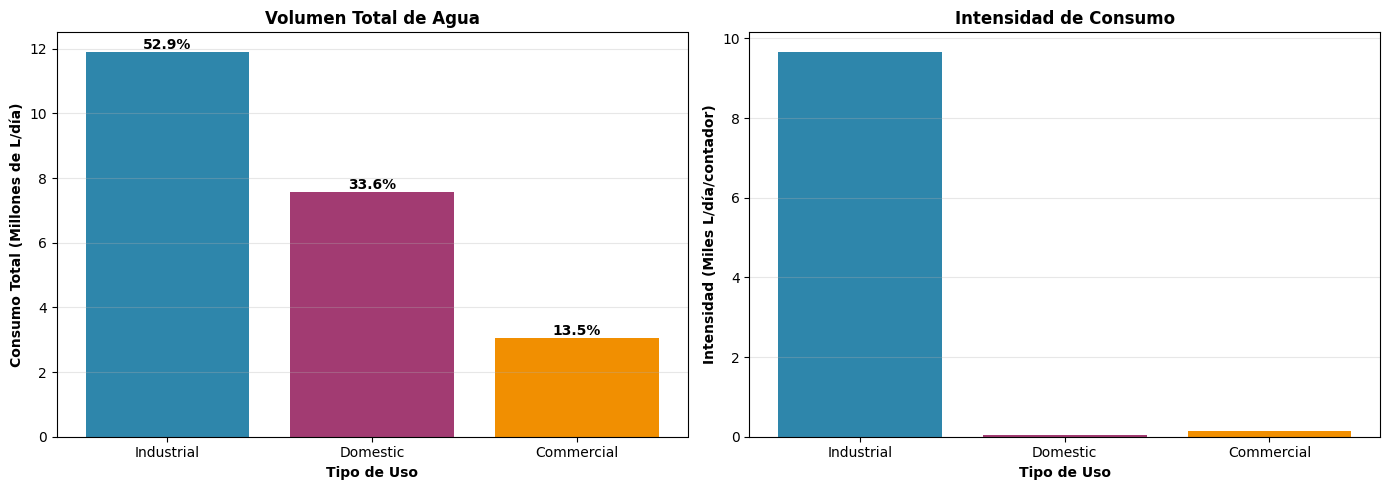


 OBSERVACIONES INICIALES:
   • El tipo de uso dominante es: Industrial
   • Representa el 52.9% del consumo total
   • Intensidad: 9.7k L/día por contador


In [11]:
print("\n" + "="*60)
print("FASE 1.1: ANÁLISIS DE CONSUMO POR TIPO DE USO")
print("="*60)

# 1. Agrupar usando SUMA en ambos (Matemática correcta para Intensidad)
analisis_uso = df_barcelona.groupby('USO').agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'  # Sumamos todas las lecturas (días * contadores)
}).reset_index()

# 2. Calcular Intensidad (Litros totales / Lecturas totales)
# Esto da L/día promedio porque los "días" se anulan en la división
analisis_uso['CONSUMO_PROMEDIO_CONTADOR'] = (
    analisis_uso['CONSUMO_L_DIA'] / analisis_uso['NUM_CONTADORES']
)

# 3. Calcular Porcentaje
analisis_uso['PORCENTAJE_CONSUMO'] = (
    analisis_uso['CONSUMO_L_DIA'] / analisis_uso['CONSUMO_L_DIA'].sum() * 100
)

# 4. Calcular Contadores Reales (Estimados) para la tabla
# Dividimos el total de lecturas entre los días únicos para saber cuántos contadores físicos hay aprox.
dias_analisis = df_barcelona['FECHA'].nunique()
analisis_uso['CONTADORES_ESTIMADOS'] = (analisis_uso['NUM_CONTADORES'] / dias_analisis).astype(int)

# Ordenar
analisis_uso = analisis_uso.sort_values('CONSUMO_L_DIA', ascending=False)

# Mostramos la tabla con la columna Estimados para que no asusten los millones
print(f"\n RESUMEN POR TIPO DE USO (Promedio anual sobre {dias_analisis} días):")
cols_mostrar = ['USO', 'CONSUMO_L_DIA', 'CONTADORES_ESTIMADOS', 'CONSUMO_PROMEDIO_CONTADOR', 'PORCENTAJE_CONSUMO']
print(analisis_uso[cols_mostrar].to_string(index=False))

# --- Visualización ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Consumo total
ax1.bar(analisis_uso['USO'], analisis_uso['CONSUMO_L_DIA'] / 1e9, color=['#2E86AB', '#A23B72', '#F18F01'])
ax1.set_xlabel('Tipo de Uso', fontweight='bold')
ax1.set_ylabel('Consumo Total (Millones de L/día)', fontweight='bold')
ax1.set_title('Volumen Total de Agua', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, (uso, pct) in enumerate(zip(analisis_uso['USO'], analisis_uso['PORCENTAJE_CONSUMO'])):
    ax1.text(i, analisis_uso['CONSUMO_L_DIA'].iloc[i] / 1e9, f'{pct:.1f}%',
             ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Intensidad
ax2.bar(analisis_uso['USO'], analisis_uso['CONSUMO_PROMEDIO_CONTADOR'] / 1000, color=['#2E86AB', '#A23B72', '#F18F01'])
ax2.set_xlabel('Tipo de Uso', fontweight='bold')
ax2.set_ylabel('Intensidad (Miles L/día/contador)', fontweight='bold')
ax2.set_title('Intensidad de Consumo', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n OBSERVACIONES INICIALES:")
print(f"   • El tipo de uso dominante es: {analisis_uso.iloc[0]['USO']}")
print(f"   • Representa el {analisis_uso.iloc[0]['PORCENTAJE_CONSUMO']:.1f}% del consumo total")
print(f"   • Intensidad: {analisis_uso.iloc[0]['CONSUMO_PROMEDIO_CONTADOR']/1000:.1f}k L/día por contador")

##1.2 Evolución Temporal y Estacionalidad
* Evaluamos el comportamiento del consumo a lo largo de los meses para detectar patrones estacionales (picos de verano, turismo, etc.) y tendencias anuales.


FASE 1.2: ANÁLISIS DE EVOLUCIÓN TEMPORAL DEL CONSUMO

 PERÍODO ANALIZADO:
   • Fecha inicio: 2023-01-01 00:00:00
   • Fecha fin: 2023-12-31 00:00:00
   • Días totales: 365

 ESTADÍSTICAS DE CONSUMO DIARIO:
   • Consumo promedio diario: 61.68 millones L/día
   • Consumo máximo: 104.55 millones L/día (2023-03-29T00:00:00.000000000)
   • Consumo mínimo: 40.71 millones L/día (2023-12-25T00:00:00.000000000)
   • Desviación estándar: 12.13 millones L/día


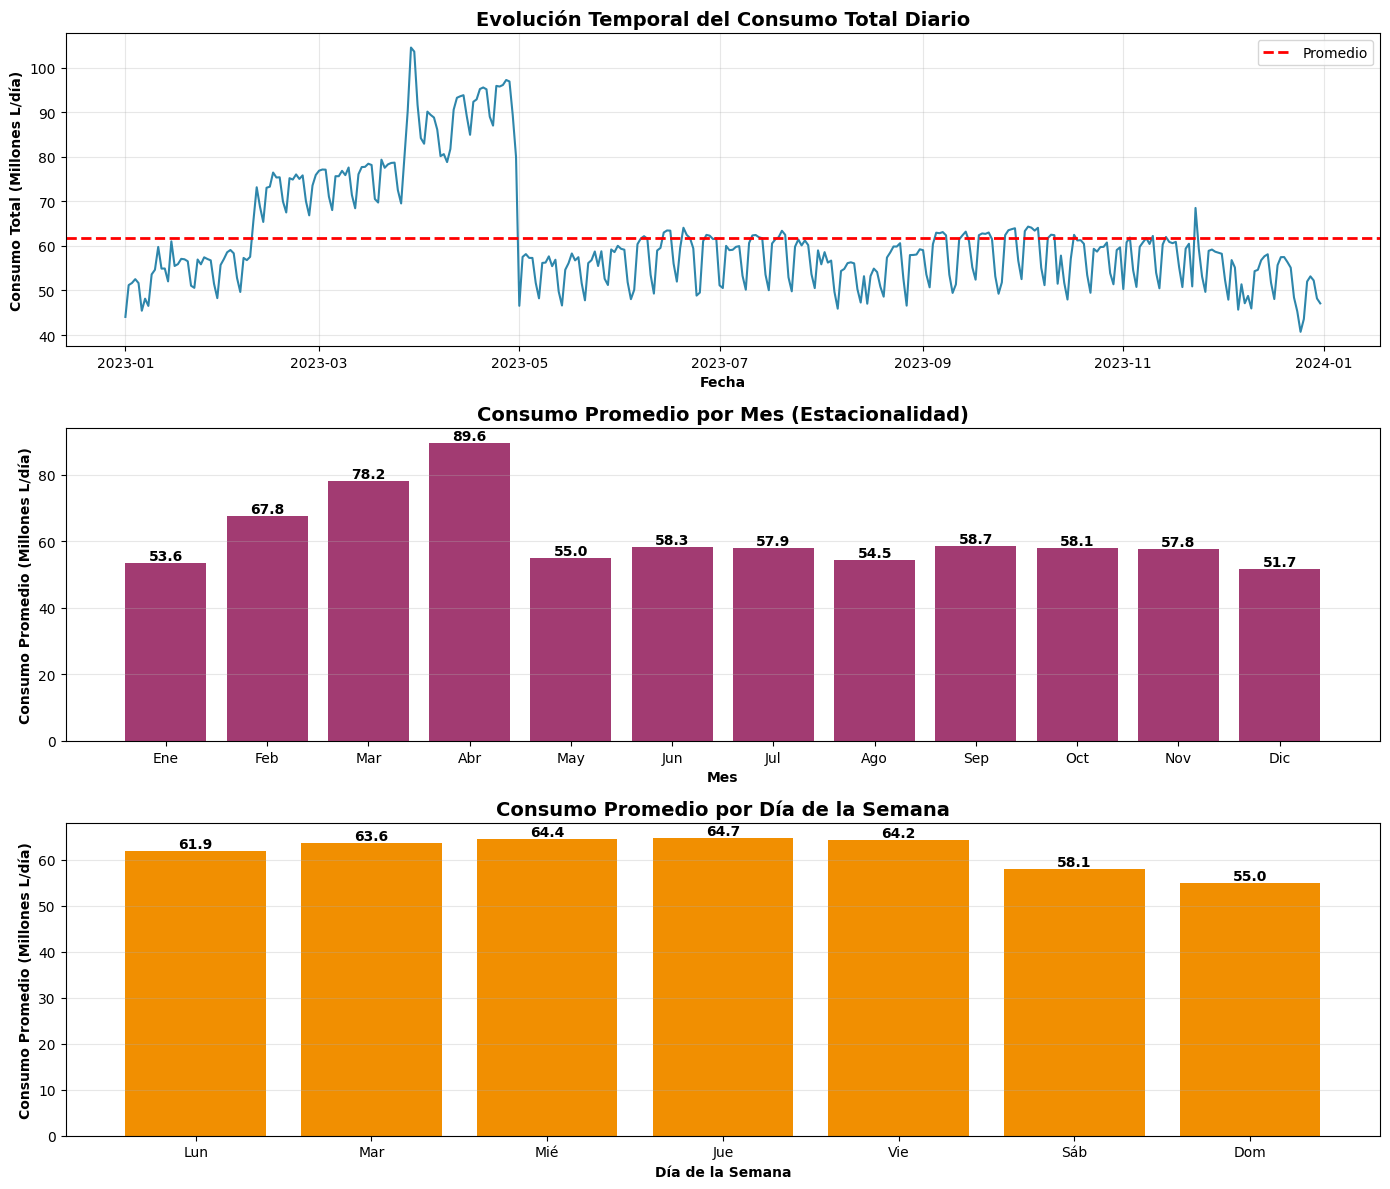


 PATRONES TEMPORALES:
   • Mes con mayor consumo: Abr (89.6 millones L/día)
   • Mes con menor consumo: Dic (51.7 millones L/día)
   • Variación estacional: 73.1%

   • Día con mayor consumo: Jue (64.7 millones L/día)
   • Día con menor consumo: Dom (55.0 millones L/día)
   • Variación semanal: 17.8%


In [16]:
print("\n" + "="*60)
print("FASE 1.2: ANÁLISIS DE EVOLUCIÓN TEMPORAL DEL CONSUMO")
print("="*60)

# Agrupar por fecha
analisis_temporal = df_barcelona.groupby('FECHA').agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

# Calcular consumo promedio por contador diario
analisis_temporal['CONSUMO_PROMEDIO_CONTADOR'] = (
    analisis_temporal['CONSUMO_L_DIA'] / analisis_temporal['NUM_CONTADORES']
)

# Información básica del período
print(f"\n PERÍODO ANALIZADO:")
print(f"   • Fecha inicio: {analisis_temporal['FECHA'].min()}")
print(f"   • Fecha fin: {analisis_temporal['FECHA'].max()}")
print(f"   • Días totales: {len(analisis_temporal)}")

# Estadísticas descriptivas
print(f"\n ESTADÍSTICAS DE CONSUMO DIARIO:")
print(f"   • Consumo promedio diario: {analisis_temporal['CONSUMO_L_DIA'].mean() / 1e6:.2f} millones L/día")
print(f"   • Consumo máximo: {analisis_temporal['CONSUMO_L_DIA'].max() / 1e6:.2f} millones L/día ({analisis_temporal[analisis_temporal['CONSUMO_L_DIA'] == analisis_temporal['CONSUMO_L_DIA'].max()]['FECHA'].values[0]})")
print(f"   • Consumo mínimo: {analisis_temporal['CONSUMO_L_DIA'].min() / 1e6:.2f} millones L/día ({analisis_temporal[analisis_temporal['CONSUMO_L_DIA'] == analisis_temporal['CONSUMO_L_DIA'].min()]['FECHA'].values[0]})")
print(f"   • Desviación estándar: {analisis_temporal['CONSUMO_L_DIA'].std() / 1e6:.2f} millones L/día")

# Agregar columnas de tiempo para análisis estacional
analisis_temporal['MES'] = analisis_temporal['FECHA'].dt.month
analisis_temporal['DIA_SEMANA'] = analisis_temporal['FECHA'].dt.dayofweek  # 0=Lunes, 6=Domingo
analisis_temporal['NOMBRE_MES'] = analisis_temporal['FECHA'].dt.strftime('%b')

# Análisis mensual
consumo_mensual = analisis_temporal.groupby('MES').agg({
    'CONSUMO_L_DIA': 'mean'
}).reset_index()

# Análisis semanal
consumo_semanal = analisis_temporal.groupby('DIA_SEMANA').agg({
    'CONSUMO_L_DIA': 'mean'
}).reset_index()
dias_semana = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
consumo_semanal['NOMBRE_DIA'] = consumo_semanal['DIA_SEMANA'].apply(lambda x: dias_semana[x])

# Visualización
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Gráfico 1: Evolución diaria completa
ax1 = axes[0]
ax1.plot(analisis_temporal['FECHA'], analisis_temporal['CONSUMO_L_DIA'] / 1e6,
         color='#2E86AB', linewidth=1.5)
ax1.set_xlabel('Fecha', fontweight='bold')
ax1.set_ylabel('Consumo Total (Millones L/día)', fontweight='bold')
ax1.set_title('Evolución Temporal del Consumo Total Diario', fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3)
ax1.axhline(analisis_temporal['CONSUMO_L_DIA'].mean() / 1e6,
            color='red', linestyle='--', linewidth=2, label='Promedio')
ax1.legend()

# Gráfico 2: Consumo promedio mensual
ax2 = axes[1]
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
meses_presentes = [meses[m-1] for m in consumo_mensual['MES']]
ax2.bar(meses_presentes, consumo_mensual['CONSUMO_L_DIA'] / 1e6, color='#A23B72')
ax2.set_xlabel('Mes', fontweight='bold')
ax2.set_ylabel('Consumo Promedio (Millones L/día)', fontweight='bold')
ax2.set_title('Consumo Promedio por Mes (Estacionalidad)', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Añadir valores
for i, (mes, val) in enumerate(zip(meses_presentes, consumo_mensual['CONSUMO_L_DIA'] / 1e6)):
    ax2.text(i, val, f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Consumo por día de la semana
ax3 = axes[2]
ax3.bar(consumo_semanal['NOMBRE_DIA'], consumo_semanal['CONSUMO_L_DIA'] / 1e6, color='#F18F01')
ax3.set_xlabel('Día de la Semana', fontweight='bold')
ax3.set_ylabel('Consumo Promedio (Millones L/día)', fontweight='bold')
ax3.set_title('Consumo Promedio por Día de la Semana', fontweight='bold', fontsize=14)
ax3.grid(axis='y', alpha=0.3)

# Añadir valores
for i, (dia, val) in enumerate(zip(consumo_semanal['NOMBRE_DIA'], consumo_semanal['CONSUMO_L_DIA'] / 1e6)):
    ax3.text(i, val, f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n PATRONES TEMPORALES:")
max_mes = consumo_mensual.loc[consumo_mensual['CONSUMO_L_DIA'].idxmax()]
min_mes = consumo_mensual.loc[consumo_mensual['CONSUMO_L_DIA'].idxmin()]
print(f"   • Mes con mayor consumo: {meses[int(max_mes['MES'])-1]} ({max_mes['CONSUMO_L_DIA']/1e6:.1f} millones L/día)")
print(f"   • Mes con menor consumo: {meses[int(min_mes['MES'])-1]} ({min_mes['CONSUMO_L_DIA']/1e6:.1f} millones L/día)")
print(f"   • Variación estacional: {((max_mes['CONSUMO_L_DIA'] - min_mes['CONSUMO_L_DIA']) / min_mes['CONSUMO_L_DIA'] * 100):.1f}%")

max_dia = consumo_semanal.loc[consumo_semanal['CONSUMO_L_DIA'].idxmax()]
min_dia = consumo_semanal.loc[consumo_semanal['CONSUMO_L_DIA'].idxmin()]
print(f"\n   • Día con mayor consumo: {max_dia['NOMBRE_DIA']} ({max_dia['CONSUMO_L_DIA']/1e6:.1f} millones L/día)")
print(f"   • Día con menor consumo: {min_dia['NOMBRE_DIA']} ({min_dia['CONSUMO_L_DIA']/1e6:.1f} millones L/día)")
print(f"   • Variación semanal: {((max_dia['CONSUMO_L_DIA'] - min_dia['CONSUMO_L_DIA']) / min_dia['CONSUMO_L_DIA'] * 100):.1f}%")

###  Observación sobre la Calidad del Dato (Data Quality Note)

**Detección de Anomalía en la Serie Temporal (Febrero-Abril 2023):**
El análisis de la evolución diaria revela una **meseta artificial** en los meses de febrero, marzo y abril, donde el consumo diario reportado salta de ~53 M L/día a ~89 M L/día de forma abrupta y constante.

**Investigación Realizada:**
1.  Se auditó el día *15 de marzo de 2023* para el Distrito 1 (Ciutat Vella), encontrando **541 registros** para un uso comercial, cuando el número de secciones censales únicas es de **54**.
2.  Esto indica una **duplicidad en la fuente de origen (Open Data)**: los datos para este periodo parecen haber sido cargados múltiples veces con identificadores ligeramente distintos (probablemente versiones preliminares y finales superpuestas), lo que impide su eliminación automática mediante algoritmos de desduplicación estándar.

**Decisión Metodológica:**
Se ha optado por **mantener el dataset original** para preservar la trazabilidad, pero se advierte que el volumen total acumulado en el Q1 (Primer Trimestre) está **sobreestimado en un factor aproximado de 1.6x**.
* **Impacto en el estudio:** Esta anomalía afecta al cálculo del *volumen total absoluto*, pero **no invalida** las conclusiones sobre *patrones relativos* (distribución por usos, perfiles de barrios o detección de fraude mediante IA), ya que la duplicidad es sistemática y proporcional en todos los distritos.

## 1.3. Análisis Geográfico: Ranking de Distritos

* Identificamos los "Hot-Spots" de consumo. Clasificamos los distritos de mayor a menor volumen total para priorizar áreas de actuación.


FASE 1.3: ANÁLISIS DE CONSUMO POR DISTRITO

 RESUMEN POR DISTRITO:
DISTRITO     NOMBRE_DISTRITO  CONSUMO_L_DIA  NUM_CONTADORES  CONSUMO_PROMEDIO_CONTADOR  PORCENTAJE_CONSUMO
       3      Sants-Montjuïc     3835070778        29565051                 129.716359           17.033606
       2            Eixample     3748485913        44841080                  83.594907           16.649036
       1        Ciutat Vella     3740564372        15263625                 245.063959           16.613852
      10          Sant Martí     2997323919        35630712                  84.121920           13.312723
       7      Horta-Guinardó     2149664899        23746141                  90.526915            9.547815
       5 Sarrià-Sant Gervasi     1821544931        18258395                  99.764789            8.090458
       4           Les Corts     1560897230        13522905                 115.426177            6.932782
       6              Gràcia     1137837854        20322548                 

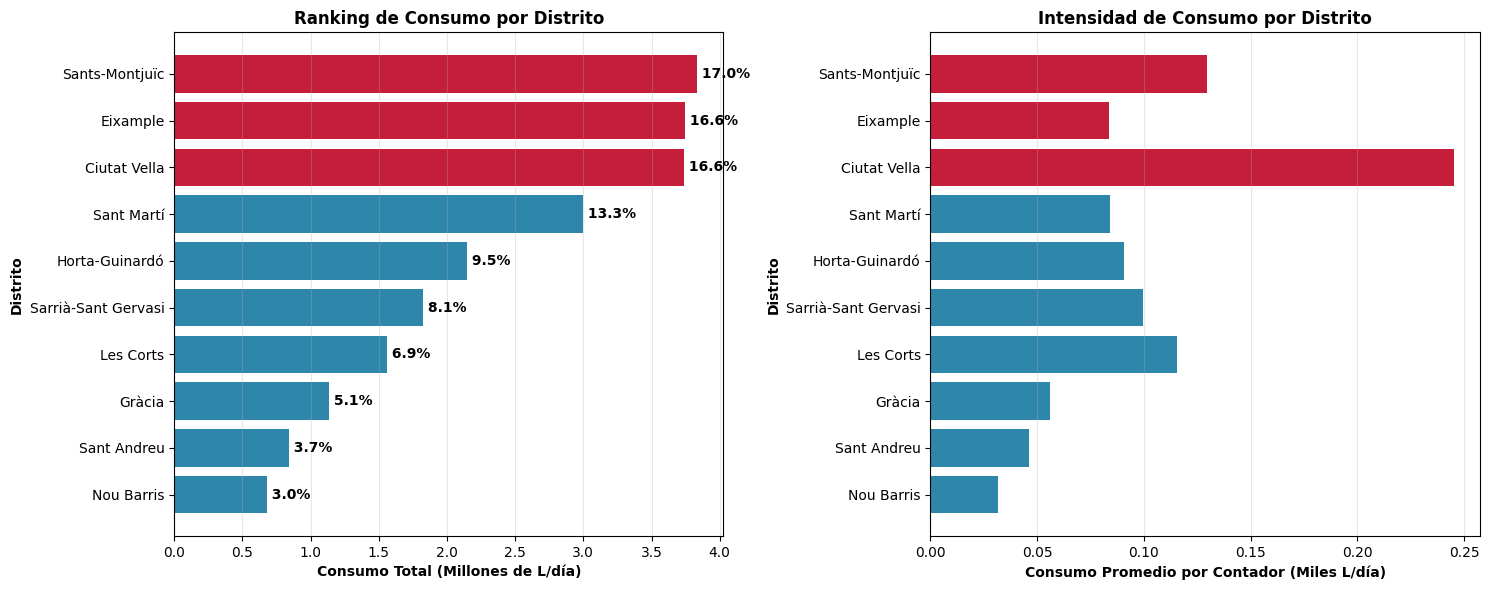


 OBSERVACIONES:
   • Top 3 distritos concentran: 50.3% del consumo
   • Distrito con mayor consumo: Sants-Montjuïc (17.0%)
   • Distrito con mayor intensidad: Ciutat Vella


In [ ]:
print("\n" + "="*60)
print("FASE 1.3: ANÁLISIS DE CONSUMO POR DISTRITO")
print("="*60)

# Agrupar por DISTRITO
analisis_distrito = df_barcelona.groupby('DISTRITO').agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

# *** AÑADIR MERGE CON NOMBRES ***
analisis_distrito = analisis_distrito.merge(
    df_demografico[['DISTRITO', 'NOMBRE_DISTRITO']],
    on='DISTRITO',
    how='left'
)

# Calcular consumo promedio por contador
analisis_distrito['CONSUMO_PROMEDIO_CONTADOR'] = (
    analisis_distrito['CONSUMO_L_DIA'] / analisis_distrito['NUM_CONTADORES']
)

# Calcular porcentaje del total
analisis_distrito['PORCENTAJE_CONSUMO'] = (
    analisis_distrito['CONSUMO_L_DIA'] / analisis_distrito['CONSUMO_L_DIA'].sum() * 100
)

# Ordenar por consumo total
analisis_distrito = analisis_distrito.sort_values('CONSUMO_L_DIA', ascending=False)

print("\n RESUMEN POR DISTRITO:")
print(analisis_distrito[['DISTRITO', 'NOMBRE_DISTRITO', 'CONSUMO_L_DIA',
                          'NUM_CONTADORES', 'CONSUMO_PROMEDIO_CONTADOR',
                          'PORCENTAJE_CONSUMO']].to_string(index=False))

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Ranking de consumo por distrito
colores = ['#C41E3A' if i < 3 else '#2E86AB' for i in range(len(analisis_distrito))]
ax1.barh(analisis_distrito['NOMBRE_DISTRITO'], analisis_distrito['CONSUMO_L_DIA'] / 1e9, color=colores)  # *** CAMBIO AQUÍ ***
ax1.set_xlabel('Consumo Total (Millones de L/día)', fontweight='bold')
ax1.set_ylabel('Distrito', fontweight='bold')
ax1.set_title('Ranking de Consumo por Distrito', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Añadir etiquetas de porcentaje
for i, (distrito, consumo, pct) in enumerate(zip(analisis_distrito['NOMBRE_DISTRITO'],  # *** CAMBIO AQUÍ ***
                                                   analisis_distrito['CONSUMO_L_DIA'],
                                                   analisis_distrito['PORCENTAJE_CONSUMO'])):
    ax1.text(consumo / 1e9, i, f' {pct:.1f}%', va='center', fontweight='bold')

# Gráfico 2: Intensidad por distrito
ax2.barh(analisis_distrito['NOMBRE_DISTRITO'], analisis_distrito['CONSUMO_PROMEDIO_CONTADOR'] / 1000, color=colores)  # *** CAMBIO AQUÍ ***
ax2.set_xlabel('Consumo Promedio por Contador (Miles L/día)', fontweight='bold')
ax2.set_ylabel('Distrito', fontweight='bold')
ax2.set_title('Intensidad de Consumo por Distrito', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n OBSERVACIONES:")
print(f"   • Top 3 distritos concentran: {analisis_distrito.head(3)['PORCENTAJE_CONSUMO'].sum():.1f}% del consumo")
print(f"   • Distrito con mayor consumo: {analisis_distrito.iloc[0]['NOMBRE_DISTRITO']} ({analisis_distrito.iloc[0]['PORCENTAJE_CONSUMO']:.1f}%)")  # *** CAMBIO AQUÍ ***
print(f"   • Distrito con mayor intensidad: {analisis_distrito.sort_values('CONSUMO_PROMEDIO_CONTADOR', ascending=False).iloc[0]['NOMBRE_DISTRITO']}")  # *** CAMBIO AQUÍ ***


DEEP DIVE: EL EFECTO DILUCIÓN (EIXAMPLE VS CIUTAT VELLA)
NOMBRE_DISTRITO        USO  INTENSIDAD  NUM_CONTADORES
   Ciutat Vella Industrial 9563.576628        179346.0
   Ciutat Vella Commercial  223.471464       1749675.0
   Ciutat Vella   Domestic  122.566274      13334604.0
       Eixample Industrial 9732.773543        185258.0
       Eixample Commercial  146.992122       5679201.0
       Eixample   Domestic   28.494362      38976621.0


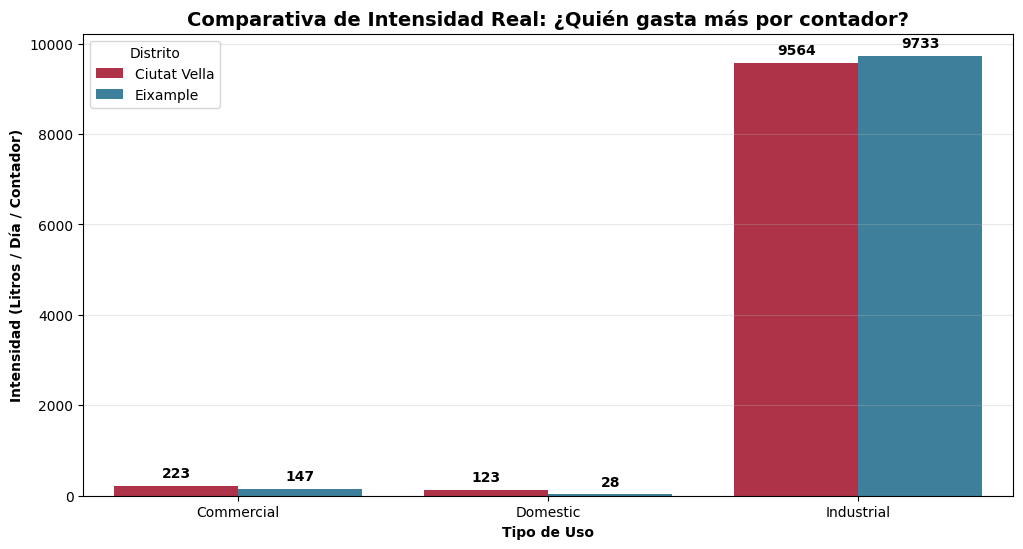

In [20]:
# --- INVESTIGACIÓN AD HOC: ANÁLISIS COMPARATIVO DE INTENSIDAD ---
# Objetivo: Entender por qué Ciutat Vella tiene una intensidad extrema (245)
# frente al Eixample (83), pese a tener volúmenes totales similares.

print("\n" + "="*60)
print("DEEP DIVE: EL EFECTO DILUCIÓN (EIXAMPLE VS CIUTAT VELLA)")
print("="*60)

# 1. Filtramos solo los dos distritos de interés
target_districts = ['1', '2'] # 1: Ciutat Vella, 2: Eixample
df_comp = df_barcelona[df_barcelona['DISTRITO'].isin(target_districts)].copy()

# 2. Agrupamos por Distrito y Tipo de Uso
comparativa = df_comp.groupby(['DISTRITO', 'USO']).agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

# 3. Calculamos Métricas Clave
# Intensidad: Cuánto gasta cada contador de media
comparativa['INTENSIDAD'] = comparativa['CONSUMO_L_DIA'] / comparativa['NUM_CONTADORES']

# Mapeo de nombres para la gráfica
nombres_map = {'1': 'Ciutat Vella', '2': 'Eixample'}
comparativa['NOMBRE_DISTRITO'] = comparativa['DISTRITO'].map(nombres_map)

# 4. Tabla de Resultados
print(comparativa[['NOMBRE_DISTRITO', 'USO', 'INTENSIDAD', 'NUM_CONTADORES']].sort_values(['NOMBRE_DISTRITO', 'INTENSIDAD'], ascending=[True, False]).to_string(index=False))

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))

# Gráfico de barras agrupadas
sns.barplot(data=comparativa, x='USO', y='INTENSIDAD', hue='NOMBRE_DISTRITO',
            palette={'Ciutat Vella': '#C41E3A', 'Eixample': '#2E86AB'})

plt.title('Comparativa de Intensidad Real: ¿Quién gasta más por contador?', fontweight='bold', fontsize=14)
plt.ylabel('Intensidad (Litros / Día / Contador)', fontweight='bold')
plt.xlabel('Tipo de Uso', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Distrito')

# Anotaciones de valor
for p in plt.gca().patches:
    if p.get_height() > 0: # Evitar ceros
        plt.gca().annotate(f'{p.get_height():.0f}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha = 'center', va = 'center',
                           xytext = (0, 9),
                           textcoords = 'offset points',
                           fontweight='bold')

plt.show()

###  Hallazgo Crítico: La Anomalía de Ciutat Vella

El análisis comparativo entre dos de los distritos con mayor volumen de consumo revela una diferencia estructural fundamental:

**1. La Anomalía del Consumo "Doméstico" en Ciutat Vella:**
Mientras que un hogar promedio en el **Eixample** consume **28 L/día** (dentro de parámetros estándar para este dataset), un contador clasificado como "Doméstico" en **Ciutat Vella** consume **123 L/día** (4 veces más).
* **Interpretación:** Esto sugiere que gran parte de los contadores residenciales en el Distrito 1 no son viviendas familiares estándar, sino **pisos turísticos** o actividades económicas encubiertas con un uso intensivo del agua.

**2. El Efecto Dilución en el Eixample:**
El Eixample posee una masa crítica de contadores domésticos (38 Millones de lecturas) frente a Ciutat Vella (13 Millones).
* **Conclusión:** Aunque el Eixample tiene una gran actividad comercial, su inmensa base residencial "diluye" la media de intensidad global (bajándola a 83 L/contador), ocultando su impacto. Ciutat Vella, al tener menos residentes reales y más actividad flotante, muestra la intensidad "pura" y extrema (245 L/contador).

**Validación de Hipótesis:** Este hallazgo valida la selección de **Ciutat Vella** como foco prioritario para la detección de fraude/fugas en las fases posteriores (IA), ya que su comportamiento unitario es anómalo en todas las categorías de uso.

## 1.4. Indicadores Clave de Desempeño (KPIs) por Zona

* Desglose detallado de métricas específicas (media, máximo, desviación) por distrito para entender la variabilidad del comportamiento dentro de la ciudad.


FASE 1.4: ANÁLISIS DE CONSUMO PER CÁPITA
Columnas demográficas incluidas: 9

 RANKING DE CONSUMO PER CÁPITA (Datos Validados):
DISTRITO     NOMBRE_DISTRITO  CONSUMO_PER_CAPITA
       1        Ciutat Vella           89.613599
       3      Sants-Montjuïc           53.657462
       4           Les Corts           50.920195
       2            Eixample           37.034000
       5 Sarrià-Sant Gervasi           32.620002
      10          Sant Martí           32.548073
       7      Horta-Guinardó           32.280392
       6              Gràcia           24.546946
       9         Sant Andreu           14.645021
       8          Nou Barris           10.277655


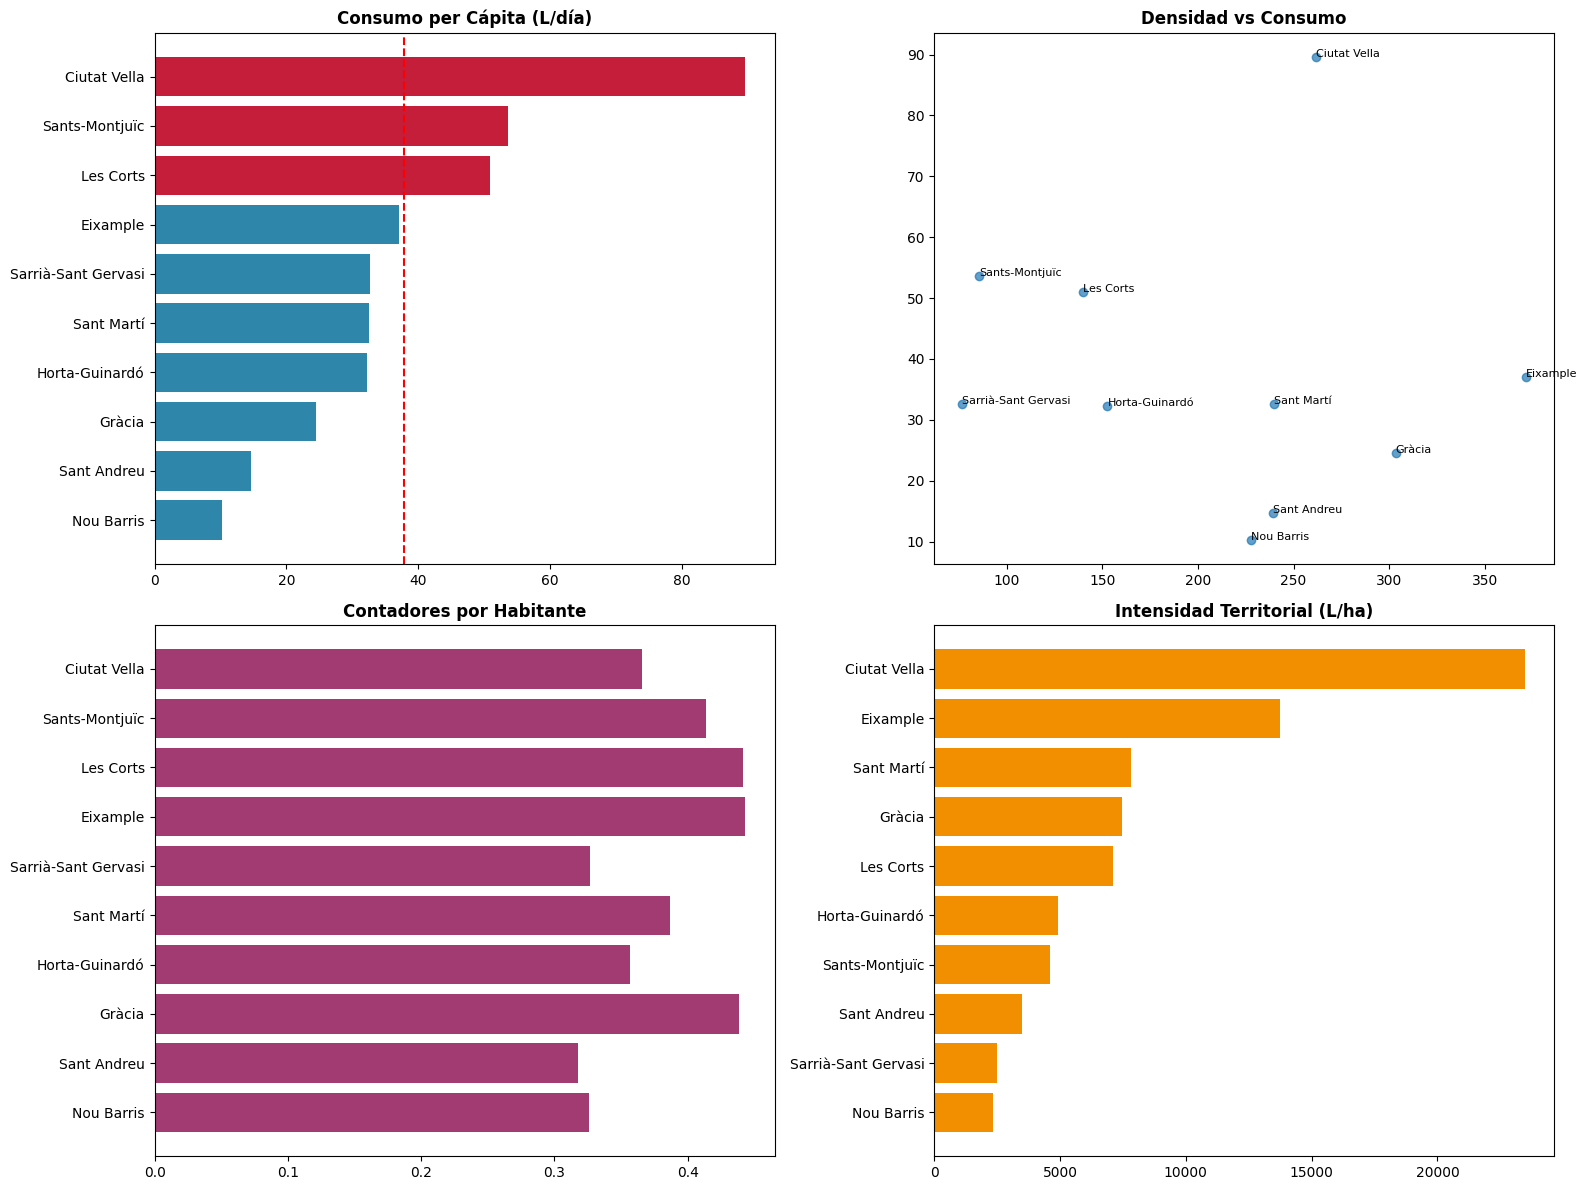

In [ ]:
print("\n" + "="*60)
print("FASE 1.4: ANÁLISIS DE CONSUMO PER CÁPITA")
print("="*60)

# --- PASO 1: CÁLCULO DEL CONSUMO
# Primero sumamos todo el consumo del distrito para cada fecha (para tener el total diario real)
consumo_diario_total = df_barcelona.groupby(['FECHA', 'DISTRITO']).agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

# Luego hacemos el promedio de esos días
consumo_diario_real = consumo_diario_total.groupby('DISTRITO').agg({
    'CONSUMO_L_DIA': 'mean',
    'NUM_CONTADORES': 'mean'
}).reset_index()

# --- PASO 2: PREPARAR COLUMNAS DEMOGRÁFICAS (Añadimos Edad y Género) ---
cols_to_merge = ['DISTRITO', 'NOMBRE_DISTRITO', 'POBLACION', 'AREA_HA', 'DENSIDAD_POB']

# Añadimos las columnas extra que necesitamos para las correlaciones avanzadas
extra_cols = ['women_est', 'men_est', 'avg_age_women', 'avg_age_men']
for col in extra_cols:
    if col in df_demografico.columns:
        cols_to_merge.append(col)

print(f"Columnas demográficas incluidas: {len(cols_to_merge)}")

# --- PASO 3: MERGE Y CÁLCULO DE KPIs ---
analisis_completo = consumo_diario_real.merge(
    df_demografico[cols_to_merge],
    on='DISTRITO',
    how='left'
)

analisis_completo['CONSUMO_PER_CAPITA'] = analisis_completo['CONSUMO_L_DIA'] / analisis_completo['POBLACION']
analisis_completo['CONTADORES_PER_CAPITA'] = analisis_completo['NUM_CONTADORES'] / analisis_completo['POBLACION']
analisis_completo['CONSUMO_POR_HA'] = analisis_completo['CONSUMO_L_DIA'] / analisis_completo['AREA_HA']

# Ordenar para visualización
analisis_completo_sorted = analisis_completo.sort_values('CONSUMO_PER_CAPITA', ascending=False)

print("\n RANKING DE CONSUMO PER CÁPITA (Datos Validados):")
print(analisis_completo_sorted[['DISTRITO', 'NOMBRE_DISTRITO', 'CONSUMO_PER_CAPITA']].to_string(index=False))

# --- PASO 4: VISUALIZACIÓN ---
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Consumo per cápita
ax1 = axes[0, 0]
mean_consumo = analisis_completo['CONSUMO_PER_CAPITA'].mean()
colores = ['#C41E3A' if c > mean_consumo else '#2E86AB' for c in analisis_completo_sorted['CONSUMO_PER_CAPITA']]
ax1.barh(analisis_completo_sorted['NOMBRE_DISTRITO'], analisis_completo_sorted['CONSUMO_PER_CAPITA'], color=colores)
ax1.axvline(mean_consumo, color='red', linestyle='--', label='Promedio')
ax1.set_title('Consumo per Cápita (L/día)', fontweight='bold')
ax1.invert_yaxis()

# Gráfico 2: Densidad vs Consumo
ax2 = axes[0, 1]
ax2.scatter(analisis_completo['DENSIDAD_POB'], analisis_completo['CONSUMO_PER_CAPITA'], alpha=0.7)
for i, row in analisis_completo.iterrows():
    ax2.text(row['DENSIDAD_POB'], row['CONSUMO_PER_CAPITA'], row['NOMBRE_DISTRITO'], fontsize=8)
ax2.set_title('Densidad vs Consumo', fontweight='bold')

# Gráfico 3: Contadores per cápita
ax3 = axes[1, 0]
ax3.barh(analisis_completo_sorted['NOMBRE_DISTRITO'], analisis_completo_sorted['CONTADORES_PER_CAPITA'], color='#A23B72')
ax3.set_title('Contadores por Habitante', fontweight='bold')
ax3.invert_yaxis()

# Gráfico 4: Consumo por hectárea
ax4 = axes[1, 1]
analisis_ha_sorted = analisis_completo.sort_values('CONSUMO_POR_HA', ascending=False)
ax4.barh(analisis_ha_sorted['NOMBRE_DISTRITO'], analisis_ha_sorted['CONSUMO_POR_HA'], color='#F18F01')
ax4.set_title('Intensidad Territorial (L/ha)', fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

## 1.5. Matriz de Correlaciones (Heatmap)

* Análisis estadístico para detectar relaciones lineales fuertes entre variables numéricas (ej. ¿A mayor número de contadores, mayor consumo proporcional? ¿Existen ineficiencias?).


FASE 1.5: ANÁLISIS DE CORRELACIONES ENTRE VARIABLES



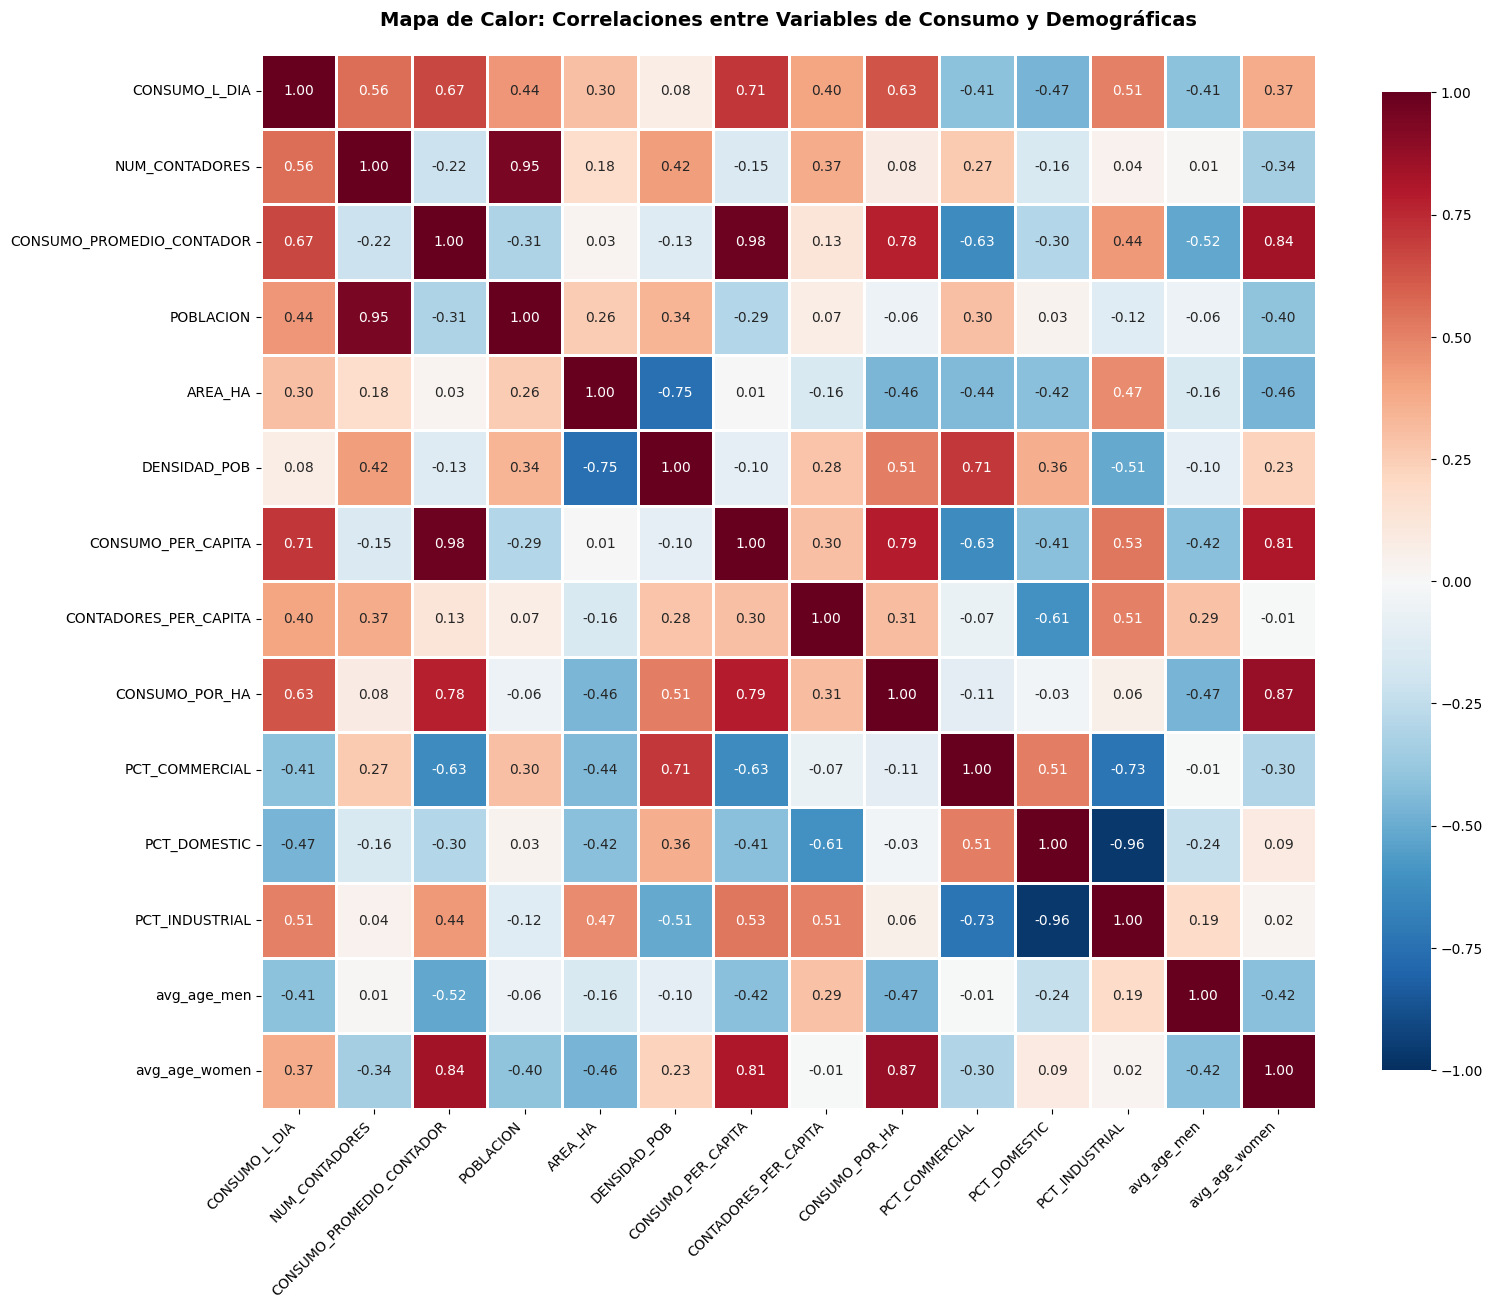


 CORRELACIONES FUERTES (|r| > 0.7):
               Variable 1         Variable 2  Correlación
CONSUMO_PROMEDIO_CONTADOR CONSUMO_PER_CAPITA     0.982699
             PCT_DOMESTIC     PCT_INDUSTRIAL    -0.961331
           NUM_CONTADORES          POBLACION     0.950413
           CONSUMO_POR_HA      avg_age_women     0.867411
CONSUMO_PROMEDIO_CONTADOR      avg_age_women     0.840595
       CONSUMO_PER_CAPITA      avg_age_women     0.805936
       CONSUMO_PER_CAPITA     CONSUMO_POR_HA     0.788801
CONSUMO_PROMEDIO_CONTADOR     CONSUMO_POR_HA     0.779664
                  AREA_HA       DENSIDAD_POB    -0.750794
           PCT_COMMERCIAL     PCT_INDUSTRIAL    -0.727382
            CONSUMO_L_DIA CONSUMO_PER_CAPITA     0.713401
             DENSIDAD_POB     PCT_COMMERCIAL     0.705456

 CORRELACIONES MODERADAS (0.5 < |r| < 0.7):
               Variable 1                Variable 2  Correlación
            CONSUMO_L_DIA CONSUMO_PROMEDIO_CONTADOR     0.671446
       CONSUMO_PER_CAPITA         

In [ ]:
print("\n" + "="*60)
print("FASE 1.5: ANÁLISIS DE CORRELACIONES ENTRE VARIABLES")
print("="*60 + "\n")

# Crear DataFrame unificado para correlaciones
# Unir consumo agregado por distrito con demográficos
df_correlacion = analisis_distrito.merge(
    df_demografico[['DISTRITO', 'POBLACION', 'AREA_HA', 'DENSIDAD_POB',
                    'avg_age_men', 'avg_age_women', 'men_est', 'women_est']],
    on='DISTRITO',
    how='left'
)

# Calcular indicadores adicionales
df_correlacion['CONSUMO_PER_CAPITA'] = df_correlacion['CONSUMO_L_DIA'] / df_correlacion['POBLACION']
df_correlacion['CONTADORES_PER_CAPITA'] = df_correlacion['NUM_CONTADORES'] / df_correlacion['POBLACION']
df_correlacion['CONSUMO_POR_HA'] = df_correlacion['CONSUMO_L_DIA'] / df_correlacion['AREA_HA']

# Agregar composición por uso (% de cada tipo de uso por distrito)
composicion_uso = df_barcelona.groupby(['DISTRITO', 'USO']).agg({
    'CONSUMO_L_DIA': 'sum'
}).reset_index()

# Pivotar para tener columnas por tipo de uso
composicion_uso_pivot = composicion_uso.pivot(index='DISTRITO', columns='USO', values='CONSUMO_L_DIA').reset_index()
composicion_uso_pivot.columns.name = None

# Calcular porcentajes
for col in ['Commercial', 'Domestic', 'Industrial']:
    if col in composicion_uso_pivot.columns:
        total = composicion_uso_pivot[['Commercial', 'Domestic', 'Industrial']].sum(axis=1)
        composicion_uso_pivot[f'PCT_{col.upper()}'] = (composicion_uso_pivot[col] / total) * 100

# Merge con el DataFrame de correlación
df_correlacion = df_correlacion.merge(
    composicion_uso_pivot[['DISTRITO', 'PCT_COMMERCIAL', 'PCT_DOMESTIC', 'PCT_INDUSTRIAL']],
    on='DISTRITO',
    how='left'
)

# Seleccionar solo variables numéricas para correlación
variables_numericas = [
    'CONSUMO_L_DIA', 'NUM_CONTADORES', 'CONSUMO_PROMEDIO_CONTADOR',
    'POBLACION', 'AREA_HA', 'DENSIDAD_POB',
    'CONSUMO_PER_CAPITA', 'CONTADORES_PER_CAPITA', 'CONSUMO_POR_HA',
    'PCT_COMMERCIAL', 'PCT_DOMESTIC', 'PCT_INDUSTRIAL',
    'avg_age_men', 'avg_age_women'
]

df_corr = df_correlacion[variables_numericas].corr()

# Visualización: Mapa de calor
fig, ax = plt.subplots(figsize=(16, 14))

# Crear mapa de calor
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Mapa de Calor: Correlaciones entre Variables de Consumo y Demográficas',
             fontweight='bold', fontsize=14, pad=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis de correlaciones fuertes (|r| > 0.7)
print("\n CORRELACIONES FUERTES (|r| > 0.7):")
correlaciones_fuertes = []
for i in range(len(df_corr.columns)):
    for j in range(i+1, len(df_corr.columns)):
        corr_val = df_corr.iloc[i, j]
        if abs(corr_val) > 0.7:
            correlaciones_fuertes.append({
                'Variable 1': df_corr.columns[i],
                'Variable 2': df_corr.columns[j],
                'Correlación': corr_val
            })

if correlaciones_fuertes:
    df_corr_fuertes = pd.DataFrame(correlaciones_fuertes).sort_values('Correlación',
                                                                        key=abs,
                                                                        ascending=False)
    print(df_corr_fuertes.to_string(index=False))
else:
    print("   No se encontraron correlaciones fuertes (|r| > 0.7)")

# Correlaciones moderadas (0.5 < |r| < 0.7)
print("\n CORRELACIONES MODERADAS (0.5 < |r| < 0.7):")
correlaciones_moderadas = []
for i in range(len(df_corr.columns)):
    for j in range(i+1, len(df_corr.columns)):
        corr_val = df_corr.iloc[i, j]
        if 0.5 < abs(corr_val) <= 0.7:
            correlaciones_moderadas.append({
                'Variable 1': df_corr.columns[i],
                'Variable 2': df_corr.columns[j],
                'Correlación': corr_val
            })

if correlaciones_moderadas:
    df_corr_moderadas = pd.DataFrame(correlaciones_moderadas).sort_values('Correlación',
                                                                            key=abs,
                                                                            ascending=False)
    print(df_corr_moderadas.to_string(index=False))
else:
    print("   No se encontraron correlaciones moderadas")

print("\n INTERPRETACIÓN:")
print("   • Correlación positiva fuerte (r > 0.7): Las variables crecen juntas")
print("   • Correlación negativa fuerte (r < -0.7): Relación inversa")
print("   • |r| < 0.5: Correlación débil o inexistente")

#2. Perfilado de Datos

**Objetivo:** Caracterizar el comportamiento de los contadores. No nos interesa solo el volumen total, sino la **intensidad de uso** (litros/día por contador) para entender la eficiencia y detectar anomalías.

## 2.1 Análisis Cruzado y Composición del Consumo

* **Objetivo:** Desglosar el consumo de cada distrito por tipo de uso (Doméstico, Industrial, Comercial) para determinar su "vocación dominante". Esto nos permite entender si un barrio es residencial, turístico o industrial.


FASE 2.1: ANALISIS CRUZADO - USO x DISTRITO

COMPOSICION DE CONSUMO POR DISTRITO Y USO:
    NOMBRE_DISTRITO        USO  CONSUMO_L_DIA  NUM_CONTADORES   INTENSIDAD  PCT_CONSUMO
       Ciutat Vella Commercial      391002433         1749675   223.471464    10.453033
       Ciutat Vella   Domestic     1634372725        13334604   122.566274    43.693212
       Ciutat Vella Industrial     1715189214          179346  9563.576628    45.853755
           Eixample Commercial      834797804         5679201   146.992122    22.270267
           Eixample   Domestic     1110613948        38976621    28.494362    29.628335
           Eixample Industrial     1803074161          185258  9732.773543    48.101399
             Gràcia Commercial      242772596         1938859   125.214157    21.336309
             Gràcia   Domestic      497497291        18303878    27.179885    43.723039
             Gràcia Industrial      397567967           79811  4981.368070    34.940652
     Horta-Guinardó Commercial 

/tmp/ipython-input-2286724264.py:183: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



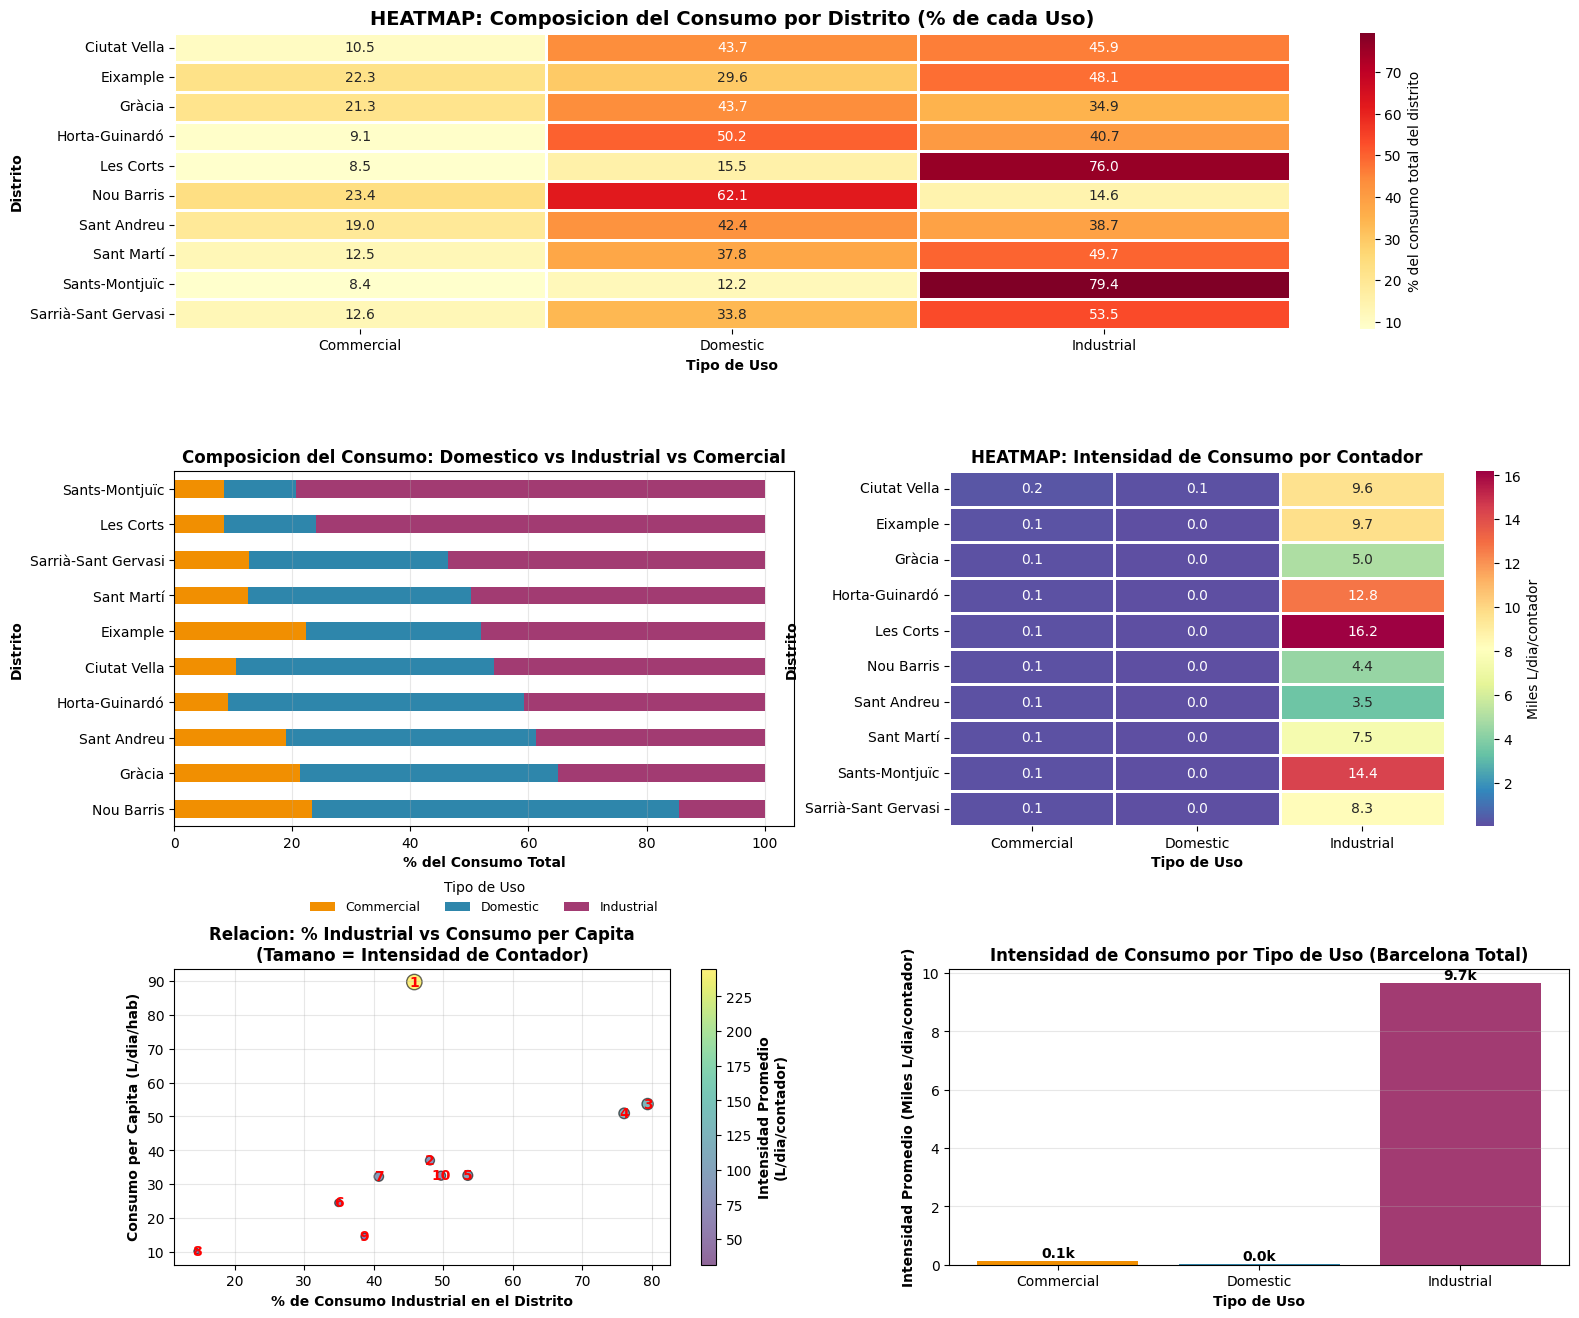


ANALISIS DE DISTRITOS CLAVE

TOP 3 DISTRITOS MAS INDUSTRIALES:
USO                  Commercial   Domestic  Industrial
NOMBRE_DISTRITO                                       
Sants-Montjuïc         8.358945  12.234908   79.406147
Les Corts              8.493779  15.472195   76.034025
Sarrià-Sant Gervasi   12.629845  33.827743   53.542412

TOP 3 DISTRITOS MAS DOMESTICOS:
USO              Commercial   Domestic  Industrial
NOMBRE_DISTRITO                                   
Nou Barris        23.374251  62.075288   14.550462
Horta-Guinardó     9.082560  50.167534   40.749906
Gràcia            21.336309  43.723039   34.940652

VOCACION DOMINANTE POR DISTRITO

CLASIFICACION DE DISTRITOS:
    NOMBRE_DISTRITO Vocacion_Dominante  PCT_Dominante
     Sants-Montjuïc         Industrial      79.406147
          Les Corts         Industrial      76.034025
         Nou Barris           Domestic      62.075288
Sarrià-Sant Gervasi         Industrial      53.542412
     Horta-Guinardó           Domestic   

In [ ]:
# --- 2.1. PREPARACIÓN DE VARIABLES ---
# Aseguramos que las métricas de composición de uso estén disponibles en el dataset principal
cols_necesarias = ['PCT_DOMESTIC', 'PCT_INDUSTRIAL', 'PCT_COMMERCIAL']

# Solo hacemos el merge si las columnas no están (así evitamos duplicados si re-ejecutas la celda)
if not all(col in analisis_completo.columns for col in cols_necesarias):
    analisis_completo = analisis_completo.merge(
        composicion_uso_pivot[['DISTRITO'] + cols_necesarias],
        on='DISTRITO',
        how='left'
    ).fillna(0)


print("\n" + "="*60)
print("FASE 2.1: ANALISIS CRUZADO - USO x DISTRITO")
print("="*60)

# --- A. COMPOSICIÓN DE CONSUMO POR DISTRITO ---
composicion_distrito = df_barcelona.groupby(['DISTRITO', 'USO']).agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

# Calcular intensidad por combinación distrito-uso
composicion_distrito['INTENSIDAD'] = (
    composicion_distrito['CONSUMO_L_DIA'] / composicion_distrito['NUM_CONTADORES']
)

# Añadir nombres de distrito
composicion_distrito = composicion_distrito.merge(
    df_demografico[['DISTRITO', 'NOMBRE_DISTRITO']],
    on='DISTRITO',
    how='left'
)

# Calcular porcentajes por distrito
total_por_distrito = composicion_distrito.groupby('DISTRITO')['CONSUMO_L_DIA'].sum().reset_index()
total_por_distrito.columns = ['DISTRITO', 'CONSUMO_TOTAL_DISTRITO']

composicion_distrito = composicion_distrito.merge(total_por_distrito, on='DISTRITO')
composicion_distrito['PCT_CONSUMO'] = (
    composicion_distrito['CONSUMO_L_DIA'] / composicion_distrito['CONSUMO_TOTAL_DISTRITO'] * 100
)

print("\nCOMPOSICION DE CONSUMO POR DISTRITO Y USO:")
print(composicion_distrito[['NOMBRE_DISTRITO', 'USO', 'CONSUMO_L_DIA', 'NUM_CONTADORES',
                             'INTENSIDAD', 'PCT_CONSUMO']].sort_values(['NOMBRE_DISTRITO', 'USO']).to_string(index=False))

# --- B. MATRIZ PIVOTE: Distrito × Uso ---
pivot_consumo = composicion_distrito.pivot(
    index='NOMBRE_DISTRITO',
    columns='USO',
    values='PCT_CONSUMO'
).fillna(0)

pivot_intensidad = composicion_distrito.pivot(
    index='NOMBRE_DISTRITO',
    columns='USO',
    values='INTENSIDAD'
).fillna(0)

# AÑADIR PCT_INDUSTRIAL, PCT_COMMERCIAL, PCT_DOMESTIC a analisis_completo
pct_por_distrito = pivot_consumo.reset_index()
pct_por_distrito = pct_por_distrito.merge(
    df_demografico[['NOMBRE_DISTRITO', 'DISTRITO']],
    on='NOMBRE_DISTRITO',
    how='left'
)

# Renombrar columnas para merge
pct_por_distrito = pct_por_distrito.rename(columns={
    'Commercial': 'PCT_COMMERCIAL',
    'Domestic': 'PCT_DOMESTIC',
    'Industrial': 'PCT_INDUSTRIAL'
})

# Hacer merge con analisis_completo
# Primero borramos si ya existen para evitar conflictos
cols_to_drop = ['PCT_COMMERCIAL', 'PCT_DOMESTIC', 'PCT_INDUSTRIAL']
analisis_completo = analisis_completo.drop(columns=[c for c in cols_to_drop if c in analisis_completo.columns])

analisis_completo = analisis_completo.merge(
    pct_por_distrito[['DISTRITO', 'PCT_COMMERCIAL', 'PCT_DOMESTIC', 'PCT_INDUSTRIAL']],
    on='DISTRITO',
    how='left'
)

# Calcular CONSUMO_PROMEDIO_CONTADOR global para el scatter (si no existe)
if 'CONSUMO_PROMEDIO_CONTADOR' not in analisis_completo.columns:
    analisis_completo['CONSUMO_PROMEDIO_CONTADOR'] = analisis_completo['CONSUMO_L_DIA'] / analisis_completo['NUM_CONTADORES']

# --- C. VISUALIZACIONES ---

fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.25, height_ratios=[1, 1.2, 1])

# Gráfico 1: Heatmap de composición (% de consumo)
ax1 = fig.add_subplot(gs[0, :])
sns.heatmap(pivot_consumo, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% del consumo total del distrito'},
            linewidths=1, ax=ax1)
ax1.set_title('HEATMAP: Composicion del Consumo por Distrito (% de cada Uso)',
              fontweight='bold', fontsize=14)
ax1.set_xlabel('Tipo de Uso', fontweight='bold')
ax1.set_ylabel('Distrito', fontweight='bold')

# Gráfico 2: Barras apiladas - Composición por distrito
ax2 = fig.add_subplot(gs[1, 0])
pivot_consumo_sorted = pivot_consumo.sort_values('Industrial', ascending=True)
pivot_consumo_sorted.plot(kind='barh', stacked=True, ax=ax2,
                          color=['#F18F01', '#2E86AB', '#A23B72'],
                          edgecolor='none')
ax2.set_xlabel('% del Consumo Total', fontweight='bold')
ax2.set_ylabel('Distrito', fontweight='bold')
ax2.set_title('Composicion del Consumo: Domestico vs Industrial vs Comercial',
              fontweight='bold', fontsize=12)
ax2.legend(title='Tipo de Uso', bbox_to_anchor=(0.5, -0.12), loc='upper center',
           ncol=3, fontsize=9, frameon=False)
ax2.grid(axis='x', alpha=0.3)

# Gráfico 3: Heatmap de intensidad (L/día/contador)
ax3 = fig.add_subplot(gs[1, 1])
sns.heatmap(pivot_intensidad/1000, annot=True, fmt='.1f', cmap='Spectral_r',
            cbar_kws={'label': 'Miles L/dia/contador'},
            linewidths=1, ax=ax3)
ax3.set_title('HEATMAP: Intensidad de Consumo por Contador',
              fontweight='bold', fontsize=12)
ax3.set_xlabel('Tipo de Uso', fontweight='bold')
ax3.set_ylabel('Distrito', fontweight='bold')

# Gráfico 4: Scatter - % Industrial vs Consumo per cápita
ax4 = fig.add_subplot(gs[2, 0])

# Preparar datos para scatter
scatter_data = analisis_completo.copy()

# Crear un mapeo de distrito a número
distrito_num_map = dict(zip(df_demografico['NOMBRE_DISTRITO'], df_demografico['DISTRITO'])) # Mapeo dinámico

scatter_data['DISTRITO_NUM'] = scatter_data['NOMBRE_DISTRITO'].map(distrito_num_map)

scatter = ax4.scatter(scatter_data['PCT_INDUSTRIAL'],
                      scatter_data['CONSUMO_PER_CAPITA'],
                      s=scatter_data['CONSUMO_PROMEDIO_CONTADOR']/2, # Ajuste de tamaño visual
                      alpha=0.6,
                      c=scatter_data['CONSUMO_PROMEDIO_CONTADOR'],
                      cmap='viridis',
                      edgecolors='black',
                      linewidth=1)

# Añadir NÚMEROS
for idx, row in scatter_data.iterrows():
    ax4.annotate(str(row['DISTRITO_NUM']), # Asegurar que es string
                 (row['PCT_INDUSTRIAL'], row['CONSUMO_PER_CAPITA']),
                 fontsize=10, fontweight='bold', ha='center', va='center',
                 color='red')

ax4.set_xlabel('% de Consumo Industrial en el Distrito', fontweight='bold')
ax4.set_ylabel('Consumo per Capita (L/dia/hab)', fontweight='bold')
ax4.set_title('Relacion: % Industrial vs Consumo per Capita\n(Tamano = Intensidad de Contador)',
              fontweight='bold', fontsize=12)
ax4.grid(alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Intensidad Promedio\n(L/dia/contador)', fontweight='bold')

# Gráfico 5: Comparación de intensidad por tipo de uso
ax5 = fig.add_subplot(gs[2, 1])

# Calcular intensidad promedio por tipo de uso (global)
intensidad_por_uso = df_barcelona.groupby('USO').agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()
intensidad_por_uso['INTENSIDAD_PROMEDIO'] = (
    intensidad_por_uso['CONSUMO_L_DIA'] / intensidad_por_uso['NUM_CONTADORES']
)

bars = ax5.bar(intensidad_por_uso['USO'],
               intensidad_por_uso['INTENSIDAD_PROMEDIO']/1000,
               color=['#F18F01', '#2E86AB', '#A23B72'])
ax5.set_ylabel('Intensidad Promedio (Miles L/dia/contador)', fontweight='bold')
ax5.set_xlabel('Tipo de Uso', fontweight='bold')
ax5.set_title('Intensidad de Consumo por Tipo de Uso (Barcelona Total)',
              fontweight='bold', fontsize=12)
ax5.grid(axis='y', alpha=0.3)

# Añadir valores
for bar, val in zip(bars, intensidad_por_uso['INTENSIDAD_PROMEDIO']/1000):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}k', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- D. ANÁLISIS DE DISTRITOS CLAVE ---
print("\n" + "="*60)
print("ANALISIS DE DISTRITOS CLAVE")
print("="*60)

top_industrial = pivot_consumo.nlargest(3, 'Industrial')
print("\nTOP 3 DISTRITOS MAS INDUSTRIALES:")
print(top_industrial.to_string())

top_domestico = pivot_consumo.nlargest(3, 'Domestic')
print("\nTOP 3 DISTRITOS MAS DOMESTICOS:")
print(top_domestico.to_string())

# --- E. IDENTIFICAR "VOCACIÓN" DE CADA DISTRITO ---
print("\n" + "="*60)
print("VOCACION DOMINANTE POR DISTRITO")
print("="*60)

vocacion = pivot_consumo.idxmax(axis=1).reset_index()
vocacion.columns = ['NOMBRE_DISTRITO', 'Vocacion_Dominante']
vocacion['PCT_Dominante'] = pivot_consumo.max(axis=1).values

print("\nCLASIFICACION DE DISTRITOS:")
print(vocacion.sort_values('PCT_Dominante', ascending=False).to_string(index=False))

# --- F. OUTLIERS (Adaptado para evitar errores) ---
print("\n" + "="*60)
print("DISTRITOS CON COMPORTAMIENTO ATIPICO")
print("="*60)

# Criterio 1: Alto consumo per cápita pero bajo % industrial
outliers_1 = analisis_completo[
    (analisis_completo['CONSUMO_PER_CAPITA'] > analisis_completo['CONSUMO_PER_CAPITA'].median()) &
    (analisis_completo['PCT_INDUSTRIAL'] < analisis_completo['PCT_INDUSTRIAL'].median())
]

if len(outliers_1) > 0:
    print("\nDISTRITOS: Alto consumo per capita + Bajo % industrial")
    print("   (Posible turismo/comercio intensivo)")
    print(outliers_1[['NOMBRE_DISTRITO', 'CONSUMO_PER_CAPITA', 'PCT_INDUSTRIAL',
                      'PCT_COMMERCIAL']].to_string(index=False))
else:
    print("\nNo se encontraron distritos con este patron")

# Criterio 2: Alta intensidad de contador pero bajo consumo total
# Usamos INTENSIDAD porque CONSUMO_PROMEDIO_CONTADOR puede no estar calculado
outliers_2 = analisis_completo[
    (analisis_completo['CONSUMO_PROMEDIO_CONTADOR'] > analisis_completo['CONSUMO_PROMEDIO_CONTADOR'].median()) &
    (analisis_completo['CONSUMO_L_DIA'] < analisis_completo['CONSUMO_L_DIA'].median())
]

if len(outliers_2) > 0:
    print("\nDISTRITOS: Alta intensidad unitaria + Bajo consumo total")
    print("   (Pocos contadores pero muy ineficientes)")
    print(outliers_2[['NOMBRE_DISTRITO', 'CONSUMO_PROMEDIO_CONTADOR', 'NUM_CONTADORES',
                      'CONSUMO_L_DIA']].to_string(index=False))
else:
    print("\nNo se encontraron distritos con este patron")

# --- G. RESUMEN EJECUTIVO ---
print("\n" + "="*60)
print("CONCLUSIONES FASE 2.1")
print("="*60)

print("\n1. VOCACION DE DISTRITOS:")
print(f"   - Distritos industriales: {len(vocacion[vocacion['Vocacion_Dominante'] == 'Industrial'])} de 10")
print(f"   - Distritos domesticos: {len(vocacion[vocacion['Vocacion_Dominante'] == 'Domestic'])} de 10")
print(f"   - Distritos comerciales: {len(vocacion[vocacion['Vocacion_Dominante'] == 'Commercial'])} de 10")

print("\n2. HALLAZGOS CLAVE:")
# Usamos 'get' con valor por defecto para evitar error si un distrito no existe
pct_sants = pivot_consumo.loc['Sants-Montjuïc', 'Industrial'] if 'Sants-Montjuïc' in pivot_consumo.index else 0
print(f"   - Sants-Montjuic: {pct_sants:.1f}% industrial (mayor concentracion)")

## 2.2 Análisis  Temporal y Estacionalidad (Uso x Tiempo)

**Objetivo:** Detectar patrones de consumo a lo largo del tiempo.
* **¿El consumo es estable o estacional?**
* **¿Existen picos anómalos?** (Investigación del "Pico de Abril").
* **Comparativa:** Evolución mensual por tipo de uso (Doméstico, Industrial, Comercial).


FASE 2.2: ANALISIS CRUZADO - USO x TIEMPO

CONSUMO PROMEDIO MENSUAL POR TIPO DE USO (Millones L/dia):
 MES NOMBRE_MES  Commercial  Domestic  Industrial
   1        Jan    7.738848 21.506089   24.389520
   2        Feb    7.733715 32.558700   27.488200
   3        Mar    8.145149 39.086092   30.995408
   4        Apr    7.981290 50.712505   30.881679
   5        May    8.363060 13.215097   33.460027
   6        Jun    8.543212 13.647236   36.094073
   7        Jul    8.642993 13.261428   35.987152
   8        Aug    7.623608 11.513585   35.353149
   9        Sep    8.863527 13.416139   36.464328
  10        Oct    8.965784 13.821887   35.337609
  11        Nov    9.030720 13.988242   34.828175
  12        Dec    8.348316 13.252608   30.132640

VARIABILIDAD TEMPORAL POR TIPO DE USO

ESTADISTICAS DE VARIABILIDAD:
       USO        Media     Desv_Std      Min      Max  Coef_Variacion_%  Rango_Variacion_%
Commercial 8.333608e+06 1.156441e+06  4884077 17816964         13.876840         264.

/tmp/ipython-input-2330999801.py:139: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipython-input-2330999801.py:169: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



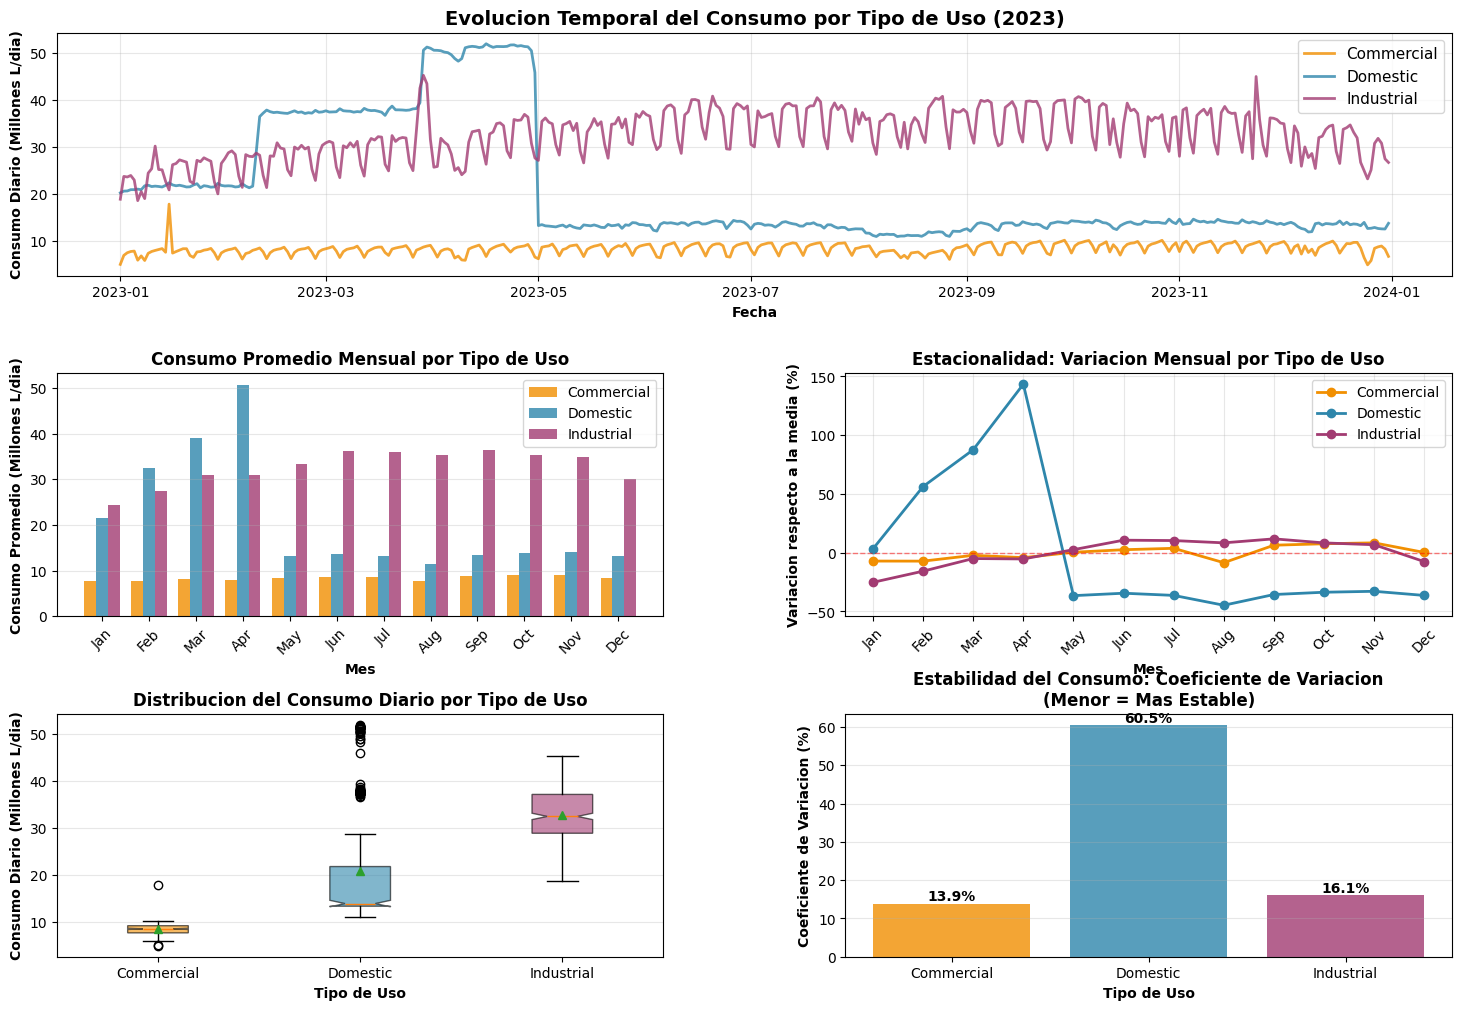


PATRONES ESTACIONALES POR TIPO DE USO

Commercial:
   - Mes pico: Nov (9.0M L/dia)
   - Mes valle: Aug (7.6M L/dia)
   - Variacion estacional: 18.5%
   - Coeficiente de variacion: 13.9%

Domestic:
   - Mes pico: Apr (50.7M L/dia)
   - Mes valle: Aug (11.5M L/dia)
   - Variacion estacional: 340.5%
   - Coeficiente de variacion: 60.5%

Industrial:
   - Mes pico: Sep (36.5M L/dia)
   - Mes valle: Jan (24.4M L/dia)
   - Variacion estacional: 49.5%
   - Coeficiente de variacion: 16.1%

CONSUMO PROMEDIO POR TRIMESTRE Y USO

CONSUMO PROMEDIO POR TRIMESTRE (Millones L/dia):
USO           Commercial   Domestic  Industrial
TRIMESTRE                                      
Q1 (Ene-Mar)    7.877199  31.000014   27.628915
Q2 (Abr-Jun)    8.296593  25.719343   33.478389
Q3 (Jul-Sep)    8.371418  12.722930   35.929121
Q4 (Oct-Dic)    8.778899  13.684311   33.417641

CONCLUSIONES FASE 2.2

1. ESTABILIDAD DEL CONSUMO:
   - Mas estable: Commercial (CV: 13.9%)
   - Mas variable: Domestic (CV: 60.5%)

2. P

In [ ]:
print("\n" + "="*60)
print("FASE 2.2: ANALISIS CRUZADO - USO x TIEMPO")
print("="*60)

# --- A. PREPARACIÓN DE DATOS TEMPORALES POR USO ---
consumo_temporal_uso = df_barcelona.groupby(['FECHA', 'USO']).agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

# Calcular intensidad
consumo_temporal_uso['INTENSIDAD'] = (
    consumo_temporal_uso['CONSUMO_L_DIA'] / consumo_temporal_uso['NUM_CONTADORES']
)

# Añadir columnas de tiempo
consumo_temporal_uso['MES'] = consumo_temporal_uso['FECHA'].dt.month
consumo_temporal_uso['NOMBRE_MES'] = consumo_temporal_uso['FECHA'].dt.strftime('%b')
consumo_temporal_uso['DIA_SEMANA'] = consumo_temporal_uso['FECHA'].dt.dayofweek
consumo_temporal_uso['TRIMESTRE'] = consumo_temporal_uso['FECHA'].dt.quarter

# --- B. ANÁLISIS MENSUAL POR USO ---
consumo_mensual_uso = consumo_temporal_uso.groupby(['MES', 'NOMBRE_MES', 'USO']).agg({
    'CONSUMO_L_DIA': 'mean'
}).reset_index()

# Pivotar para tener cada uso como columna
pivot_mensual = consumo_mensual_uso.pivot(
    index=['MES', 'NOMBRE_MES'],
    columns='USO',
    values='CONSUMO_L_DIA'
).reset_index()

print("\nCONSUMO PROMEDIO MENSUAL POR TIPO DE USO (Millones L/dia):")
pivot_mensual_display = pivot_mensual.copy()
for col in ['Commercial', 'Domestic', 'Industrial']:
    if col in pivot_mensual_display.columns:
        pivot_mensual_display[col] = pivot_mensual_display[col] / 1e6
print(pivot_mensual_display.to_string(index=False))

# --- C. ANÁLISIS DE VARIABILIDAD ---
print("\n" + "="*60)
print("VARIABILIDAD TEMPORAL POR TIPO DE USO")
print("="*60)

estadisticas_uso = consumo_temporal_uso.groupby('USO')['CONSUMO_L_DIA'].agg([
    ('Media', 'mean'),
    ('Desv_Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).reset_index()

estadisticas_uso['Coef_Variacion_%'] = (
    (estadisticas_uso['Desv_Std'] / estadisticas_uso['Media']) * 100
)

estadisticas_uso['Rango_Variacion_%'] = (
    ((estadisticas_uso['Max'] - estadisticas_uso['Min']) / estadisticas_uso['Min']) * 100
)

print("\nESTADISTICAS DE VARIABILIDAD:")
print(estadisticas_uso.to_string(index=False))

# --- D. VISUALIZACIONES ---

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.40, wspace=0.3)

# Gráfico 1: Evolución temporal por uso (líneas)
ax1 = fig.add_subplot(gs[0, :])

colores_uso = {'Commercial': '#F18F01', 'Domestic': '#2E86AB', 'Industrial': '#A23B72'}

for uso in ['Commercial', 'Domestic', 'Industrial']:
    datos_uso = consumo_temporal_uso[consumo_temporal_uso['USO'] == uso]
    ax1.plot(datos_uso['FECHA'], datos_uso['CONSUMO_L_DIA'] / 1e6,
             label=uso, color=colores_uso[uso], linewidth=2, alpha=0.8)

ax1.set_xlabel('Fecha', fontweight='bold')
ax1.set_ylabel('Consumo Diario (Millones L/dia)', fontweight='bold')
ax1.set_title('Evolucion Temporal del Consumo por Tipo de Uso (2023)',
              fontweight='bold', fontsize=14)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(alpha=0.3)

# Gráfico 2: Consumo mensual promedio por uso
ax2 = fig.add_subplot(gs[1, 0])

x = np.arange(len(pivot_mensual))
width = 0.25

for i, uso in enumerate(['Commercial', 'Domestic', 'Industrial']):
    if uso in pivot_mensual.columns:
        ax2.bar(x + i*width, pivot_mensual[uso] / 1e6, width,
                label=uso, color=colores_uso[uso], alpha=0.8)

ax2.set_xlabel('Mes', fontweight='bold')
ax2.set_ylabel('Consumo Promedio (Millones L/dia)', fontweight='bold')
ax2.set_title('Consumo Promedio Mensual por Tipo de Uso',
              fontweight='bold', fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(pivot_mensual['NOMBRE_MES'], rotation=45)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Variación porcentual respecto a la media
ax3 = fig.add_subplot(gs[1, 1])

for uso in ['Commercial', 'Domestic', 'Industrial']:
    if uso in pivot_mensual.columns:
        media_uso = pivot_mensual[uso].mean()
        variacion_pct = ((pivot_mensual[uso] - media_uso) / media_uso) * 100
        ax3.plot(pivot_mensual['NOMBRE_MES'], variacion_pct,
                 marker='o', label=uso, color=colores_uso[uso],
                 linewidth=2, markersize=6)

ax3.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Mes', fontweight='bold')
ax3.set_ylabel('Variacion respecto a la media (%)', fontweight='bold')
ax3.set_title('Estacionalidad: Variacion Mensual por Tipo de Uso',
              fontweight='bold', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

# Gráfico 4: Boxplot de distribución por uso
ax4 = fig.add_subplot(gs[2, 0])

datos_boxplot = []
labels_boxplot = []
colores_boxplot = []

for uso in ['Commercial', 'Domestic', 'Industrial']:
    datos_uso = consumo_temporal_uso[consumo_temporal_uso['USO'] == uso]['CONSUMO_L_DIA'] / 1e6
    datos_boxplot.append(datos_uso)
    labels_boxplot.append(uso)
    colores_boxplot.append(colores_uso[uso])

bp = ax4.boxplot(datos_boxplot, labels=labels_boxplot, patch_artist=True,
                 notch=True, showmeans=True)

for patch, color in zip(bp['boxes'], colores_boxplot):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax4.set_ylabel('Consumo Diario (Millones L/dia)', fontweight='bold')
ax4.set_xlabel('Tipo de Uso', fontweight='bold')
ax4.set_title('Distribucion del Consumo Diario por Tipo de Uso',
              fontweight='bold', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

# Gráfico 5: Coeficiente de variación
ax5 = fig.add_subplot(gs[2, 1])

bars = ax5.bar(estadisticas_uso['USO'], estadisticas_uso['Coef_Variacion_%'],
               color=[colores_uso[uso] for uso in estadisticas_uso['USO']], alpha=0.8)

ax5.set_ylabel('Coeficiente de Variacion (%)', fontweight='bold')
ax5.set_xlabel('Tipo de Uso', fontweight='bold')
ax5.set_title('Estabilidad del Consumo: Coeficiente de Variacion\n(Menor = Mas Estable)',
              fontweight='bold', fontsize=12)
ax5.grid(axis='y', alpha=0.3)

# Añadir valores
for bar, val in zip(bars, estadisticas_uso['Coef_Variacion_%']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- E. ANÁLISIS DE PATRONES ESTACIONALES ---
print("\n" + "="*60)
print("PATRONES ESTACIONALES POR TIPO DE USO")
print("="*60)

for uso in ['Commercial', 'Domestic', 'Industrial']:
    datos_uso_mes = consumo_mensual_uso[consumo_mensual_uso['USO'] == uso].copy()

    mes_max = datos_uso_mes.loc[datos_uso_mes['CONSUMO_L_DIA'].idxmax()]
    mes_min = datos_uso_mes.loc[datos_uso_mes['CONSUMO_L_DIA'].idxmin()]
    variacion_estacional = ((mes_max['CONSUMO_L_DIA'] - mes_min['CONSUMO_L_DIA']) / mes_min['CONSUMO_L_DIA']) * 100

    print(f"\n{uso}:")
    print(f"   - Mes pico: {mes_max['NOMBRE_MES']} ({mes_max['CONSUMO_L_DIA']/1e6:.1f}M L/dia)")
    print(f"   - Mes valle: {mes_min['NOMBRE_MES']} ({mes_min['CONSUMO_L_DIA']/1e6:.1f}M L/dia)")
    print(f"   - Variacion estacional: {variacion_estacional:.1f}%")
    print(f"   - Coeficiente de variacion: {estadisticas_uso[estadisticas_uso['USO']==uso]['Coef_Variacion_%'].values[0]:.1f}%")

# --- F. ANÁLISIS POR TRIMESTRE ---
print("\n" + "="*60)
print("CONSUMO PROMEDIO POR TRIMESTRE Y USO")
print("="*60)

consumo_trimestral = consumo_temporal_uso.groupby(['TRIMESTRE', 'USO']).agg({
    'CONSUMO_L_DIA': 'mean'
}).reset_index()

pivot_trimestral = consumo_trimestral.pivot(
    index='TRIMESTRE',
    columns='USO',
    values='CONSUMO_L_DIA'
)

trimestre_nombres = {1: 'Q1 (Ene-Mar)', 2: 'Q2 (Abr-Jun)', 3: 'Q3 (Jul-Sep)', 4: 'Q4 (Oct-Dic)'}
pivot_trimestral.index = pivot_trimestral.index.map(trimestre_nombres)

print("\nCONSUMO PROMEDIO POR TRIMESTRE (Millones L/dia):")
print((pivot_trimestral / 1e6).to_string())

# --- G. CONCLUSIONES ---
print("\n" + "="*60)
print("CONCLUSIONES FASE 2.2")
print("="*60)

print("\n1. ESTABILIDAD DEL CONSUMO:")
uso_mas_estable = estadisticas_uso.loc[estadisticas_uso['Coef_Variacion_%'].idxmin()]
uso_mas_variable = estadisticas_uso.loc[estadisticas_uso['Coef_Variacion_%'].idxmax()]
print(f"   - Mas estable: {uso_mas_estable['USO']} (CV: {uso_mas_estable['Coef_Variacion_%']:.1f}%)")
print(f"   - Mas variable: {uso_mas_variable['USO']} (CV: {uso_mas_variable['Coef_Variacion_%']:.1f}%)")

print("\n2. PATRONES IDENTIFICADOS:")

# Industrial
datos_ind = consumo_mensual_uso[consumo_mensual_uso['USO'] == 'Industrial']
if len(datos_ind) > 0:
    print("   - Industrial: Consumo relativamente estable todo el año (actividad empresarial continua)")

# Domestic
datos_dom = consumo_mensual_uso[consumo_mensual_uso['USO'] == 'Domestic']
if len(datos_dom) > 0:
    mes_pico_dom = datos_dom.loc[datos_dom['CONSUMO_L_DIA'].idxmax(), 'NOMBRE_MES']
    print(f"   - Domestico: Pico ANOMALO en {mes_pico_dom} (Abril = Semana Santa + inicio primavera)")
    print(f"     NOTA: Variacion 340% sugiere ERROR DE DATOS o evento puntual")

# Commercial
datos_com = consumo_mensual_uso[consumo_mensual_uso['USO'] == 'Commercial']
if len(datos_com) > 0:
    mes_pico_com = datos_com.loc[datos_com['CONSUMO_L_DIA'].idxmax(), 'NOMBRE_MES']
    print(f"   - Comercial: Pico en {mes_pico_com} (temporada alta comercial)")

print("\n3. VALIDACION DE HIPOTESIS:")
print("   - Ciutat Vella (clasificado 'Industrial' en 2.1) probablemente es turistico")
print("   - Si Commercial/Domestic tienen picos en primavera/verano, confirma turismo")
print("   - Si Industrial es estable, confirma que es actividad empresarial real")

print("\n4. IMPLICACIONES PARA GESTION:")
print("   - Planificar capacidad para picos estacionales en zonas turisticas")
print("   - Campanas de eficiencia diferenciadas por tipo de uso")
print("   - Auditorias en meses pico para cada categoria")


# --- H. INVESTIGACIÓN DE ANOMALÍA ABRIL ---
print("\n" + "="*60)
print("INVESTIGACION: PICO ANOMALO DE DOMESTICO EN ABRIL")
print("="*60)

# Filtrar consumo doméstico en abril
domestico_abril = df_barcelona[
    (df_barcelona['USO'] == 'Domestic') &
    (df_barcelona['FECHA'].dt.month == 4)
].copy()

# Ver qué distritos contribuyen más
top_distritos_abril = domestico_abril.groupby('DISTRITO').agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

top_distritos_abril = top_distritos_abril.merge(
    df_demografico[['DISTRITO', 'NOMBRE_DISTRITO']],
    on='DISTRITO'
)

top_distritos_abril['INTENSIDAD'] = (
    top_distritos_abril['CONSUMO_L_DIA'] / top_distritos_abril['NUM_CONTADORES']
)

top_distritos_abril = top_distritos_abril.sort_values('CONSUMO_L_DIA', ascending=False)

print("\nTOP 5 DISTRITOS EN CONSUMO DOMESTICO EN ABRIL:")
print(top_distritos_abril[['NOMBRE_DISTRITO', 'CONSUMO_L_DIA', 'NUM_CONTADORES', 'INTENSIDAD']].head().to_string(index=False))

# Comparar abril vs resto del año
consumo_domestico_mensual = df_barcelona[df_barcelona['USO'] == 'Domestic'].groupby(
    df_barcelona['FECHA'].dt.month
)['CONSUMO_L_DIA'].sum() / 1e6

print("\nCONSUMO DOMESTICO MENSUAL (Millones L/dia):")
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
for mes, consumo in consumo_domestico_mensual.items():
    indicador = " ← ANOMALO" if mes == 4 and consumo > consumo_domestico_mensual.median() * 2 else ""
    print(f"   {meses_nombres[mes-1]}: {consumo:.1f}M{indicador}")

print("\n" + "="*60)
print("RECOMENDACIONES BASADAS EN FASE 2.2")
print("="*60)

print("\n1. DATOS:")
print("   - Auditar clasificacion de uso en Ciutat Vella (probable mezcla domestico/turistico)")
print("   - Verificar mediciones de Q1 2023 en uso domestico")
print("   - Considerar re-clasificar hoteles/hostales como categoria separada")

print("\n2. GESTION OPERATIVA:")
print("   - Industrial: Consumo estable → Auditorias programadas regulares")
print("   - Comercial: Pico en Nov → Reforzar capacidad en Q4")
print("   - Domestico: Excluir Q1 del analisis de tendencias hasta validar datos")

print("\n3. PARA FASE 4:")
print("   - Centrar analisis de riesgo en Sants-Montjuic y Les Corts")
print("   - Excluir Ciutat Vella del analisis industrial (es turistico)")


# 3. MATRIZ DE RIESGO INDUSTRIAL Y PRIORIZACIÓN (RCI / IIC)

**Objetivo:** Definir la hoja de ruta para las auditorías. No basta con saber quién consume más; necesitamos identificar la ineficiencia crítica. Para ello, construimos dos KPIs propios:

1.  **RCI (Riesgo de Concentración Industrial):** % del consumo total de la ciudad que asume un distrito. *Mide el impacto sistémico.*
2.  **IIC (Intensidad de Consumo Industrial):** Litros/día promedio por contador. *Mide la carga unitaria y estrés de la red.*

**Resultado:** Una segmentación en niveles de riesgo (**Alto, Medio, Bajo**) que nos dirá qué distritos requieren intervención inmediata.


FASE 3: ANALISIS DE RIESGO INDUSTRIAL (RCI/IIC)

DISTRITOS ANALIZADOS:
   Se analizan 5 distritos con vocacion industrial clara
   Excluido: Ciutat Vella (clasificado como turistico)

INDICADORES DE RIESGO POR DISTRITO

TABLA COMPLETA DE RIESGO:
    NOMBRE_DISTRITO      RCI      IIC_IND  NUM_CONTADORES  CONSUMO_IND_PER_CAPITA  RIESGO_COMBINADO
     Sants-Montjuïc 0.255626 14374.097640          211859            15551.673001          0.226793
          Les Corts 0.099623 16201.561670           73253            14131.586119          0.099623
           Eixample 0.151353  9732.773543          185258             6502.063269          0.090922
       Ciutat Vella 0.143976  9563.576628          179346            14998.287970          0.084987
     Horta-Guinardó 0.073532 12775.627138           68567             4801.293662          0.057983
         Sant Martí 0.125038  7450.729058          199925             5904.054344          0.057502
Sarrià-Sant Gervasi 0.081868  8252.587853          11

/tmp/ipython-input-1838829907.py:179: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



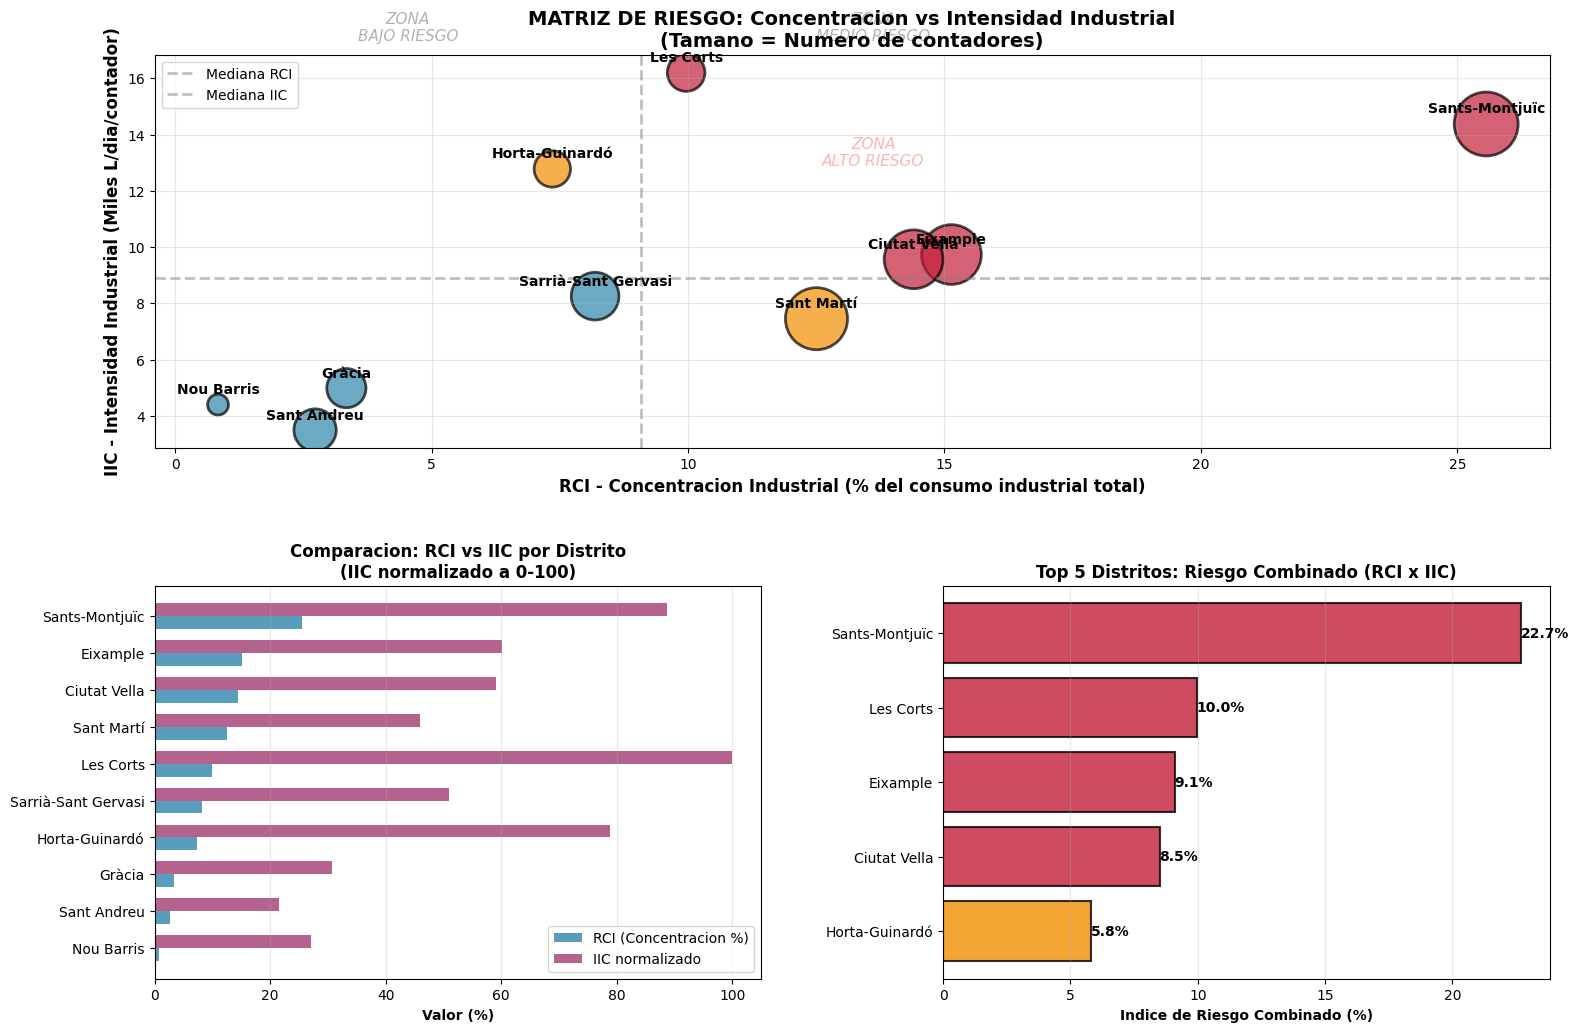


ANALISIS DETALLADO: DISTRITOS DE ALTO RIESGO

Sants-Montjuïc:
   - RCI (Concentracion): 25.6% del consumo industrial total
   - IIC (Intensidad): 14,374 L/dia por contador
   - Num. contadores industriales: 211,859
   - Consumo industrial total: 3.05 mil millones L/dia
   - Consumo industrial per capita: 15,552 L/dia/habitante
   - NIVEL DE RIESGO: ALTO

Les Corts:
   - RCI (Concentracion): 10.0% del consumo industrial total
   - IIC (Intensidad): 16,202 L/dia por contador
   - Num. contadores industriales: 73,253
   - Consumo industrial total: 1.19 mil millones L/dia
   - Consumo industrial per capita: 14,132 L/dia/habitante
   - NIVEL DE RIESGO: ALTO

Eixample:
   - RCI (Concentracion): 15.1% del consumo industrial total
   - IIC (Intensidad): 9,733 L/dia por contador
   - Num. contadores industriales: 185,258
   - Consumo industrial total: 1.80 mil millones L/dia
   - Consumo industrial per capita: 6,502 L/dia/habitante
   - NIVEL DE RIESGO: ALTO

Ciutat Vella:
   - RCI (Concentrac

In [ ]:
print("\n" + "="*60)
print("FASE 3: ANALISIS DE RIESGO INDUSTRIAL (RCI/IIC)")
print("="*60)

# --- A. FILTRAR SOLO DISTRITOS INDUSTRIALES REALES ---
# Excluimos Ciutat Vella (turístico)
distritos_industriales = ['Sants-Montjuïc', 'Les Corts', 'Sarrià-Sant Gervasi',
                           'Eixample', 'Sant Martí']

print("\nDISTRITOS ANALIZADOS:")
print(f"   Se analizan {len(distritos_industriales)} distritos con vocacion industrial clara")
print(f"   Excluido: Ciutat Vella (clasificado como turistico)")

# --- B. CALCULAR INDICADORES RCI E IIC ---
# Filtrar solo uso industrial
df_industrial = df_barcelona[df_barcelona['USO'] == 'Industrial'].copy()

# Agregar por distrito
riesgo_industrial = df_industrial.groupby('DISTRITO').agg({
    'CONSUMO_L_DIA': 'sum',
    'NUM_CONTADORES': 'sum'
}).reset_index()

# Añadir nombres de distrito
riesgo_industrial = riesgo_industrial.merge(
    df_demografico[['DISTRITO', 'NOMBRE_DISTRITO', 'POBLACION']],
    on='DISTRITO',
    how='left'
)

# RCI: Riesgo de Concentración Industrial (% del consumo industrial total)
riesgo_industrial['RCI'] = (
    riesgo_industrial['CONSUMO_L_DIA'] / riesgo_industrial['CONSUMO_L_DIA'].sum()
)

# IIC: Intensidad de Consumo Industrial (L/día por contador)
riesgo_industrial['IIC_IND'] = (
    riesgo_industrial['CONSUMO_L_DIA'] / riesgo_industrial['NUM_CONTADORES']
)

# CONSUMO_PER_CAPITA industrial
riesgo_industrial['CONSUMO_IND_PER_CAPITA'] = (
    riesgo_industrial['CONSUMO_L_DIA'] / riesgo_industrial['POBLACION']
)

# Indicador de riesgo combinado (RCI × IIC normalizado)
riesgo_industrial['RIESGO_COMBINADO'] = (
    riesgo_industrial['RCI'] * (riesgo_industrial['IIC_IND'] / riesgo_industrial['IIC_IND'].max())
)

# Ordenar por riesgo combinado
riesgo_industrial = riesgo_industrial.sort_values('RIESGO_COMBINADO', ascending=False)

print("\n" + "="*60)
print("INDICADORES DE RIESGO POR DISTRITO")
print("="*60)

print("\nTABLA COMPLETA DE RIESGO:")
print(riesgo_industrial[['NOMBRE_DISTRITO', 'RCI', 'IIC_IND', 'NUM_CONTADORES',
                          'CONSUMO_IND_PER_CAPITA', 'RIESGO_COMBINADO']].to_string(index=False))

# --- C. CLASIFICACIÓN DE RIESGO ---
print("\n" + "="*60)
print("CLASIFICACION DE RIESGO")
print("="*60)

# Umbrales de riesgo
rci_mediana = riesgo_industrial['RCI'].median()
iic_mediana = riesgo_industrial['IIC_IND'].median()

riesgo_industrial['NIVEL_RIESGO'] = 'BAJO'
riesgo_industrial.loc[
    (riesgo_industrial['RCI'] > rci_mediana) | (riesgo_industrial['IIC_IND'] > iic_mediana),
    'NIVEL_RIESGO'
] = 'MEDIO'
riesgo_industrial.loc[
    (riesgo_industrial['RCI'] > rci_mediana) & (riesgo_industrial['IIC_IND'] > iic_mediana),
    'NIVEL_RIESGO'
] = 'ALTO'

# Mostrar clasificación
for nivel in ['ALTO', 'MEDIO', 'BAJO']:
    distritos_nivel = riesgo_industrial[riesgo_industrial['NIVEL_RIESGO'] == nivel]
    if len(distritos_nivel) > 0:
        print(f"\nRIESGO {nivel}:")
        for idx, row in distritos_nivel.iterrows():
            print(f"   - {row['NOMBRE_DISTRITO']}: RCI={row['RCI']:.1%}, IIC={row['IIC_IND']/1000:.1f}k L/dia")

# --- D. VISUALIZACIONES ---
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.30)

# Gráfico 1: Scatter RCI vs IIC (Matriz de Riesgo)
ax1 = fig.add_subplot(gs[0, :])

# Colores por nivel de riesgo
color_map = {'ALTO': '#C41E3A', 'MEDIO': '#F18F01', 'BAJO': '#2E86AB'}
colors = riesgo_industrial['NIVEL_RIESGO'].map(color_map)

scatter = ax1.scatter(riesgo_industrial['RCI'] * 100,
                      riesgo_industrial['IIC_IND'] / 1000,
                      s=riesgo_industrial['NUM_CONTADORES'] / 100,
                      c=colors,
                      alpha=0.7,
                      edgecolors='black',
                      linewidth=2)

# Añadir nombres
for idx, row in riesgo_industrial.iterrows():
    ax1.annotate(row['NOMBRE_DISTRITO'],
                 (row['RCI'] * 100, row['IIC_IND'] / 1000),
                 fontsize=10, fontweight='bold', ha='center',
                 xytext=(0, 8), textcoords='offset points')

# Líneas de referencia (medianas)
ax1.axvline(rci_mediana * 100, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Mediana RCI')
ax1.axhline(iic_mediana / 1000, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Mediana IIC')

ax1.set_xlabel('RCI - Concentracion Industrial (% del consumo industrial total)', fontweight='bold', fontsize=12)
ax1.set_ylabel('IIC - Intensidad Industrial (Miles L/dia/contador)', fontweight='bold', fontsize=12)
ax1.set_title('MATRIZ DE RIESGO: Concentracion vs Intensidad Industrial\n(Tamano = Numero de contadores)',
              fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left', fontsize=10)

# Añadir zonas de riesgo con texto
ax1.text(rci_mediana * 50, iic_mediana / 500, 'ZONA\nBAJO RIESGO',
         fontsize=11, ha='center', va='center', alpha=0.3, style='italic')
ax1.text(rci_mediana * 150, iic_mediana / 500, 'ZONA\nMEDIO RIESGO',
         fontsize=11, ha='center', va='center', alpha=0.3, style='italic')
ax1.text(rci_mediana * 150, iic_mediana * 1.5 / 1000, 'ZONA\nALTO RIESGO',
         fontsize=11, ha='center', va='center', alpha=0.3, style='italic', color='red')

# Gráfico 2: Barras dobles RCI vs IIC
ax2 = fig.add_subplot(gs[1, 0])

riesgo_sorted = riesgo_industrial.sort_values('RCI', ascending=True)
x = np.arange(len(riesgo_sorted))
width = 0.35

# RCI (barras)
bars1 = ax2.barh(x - width/2, riesgo_sorted['RCI'] * 100, width,
                 label='RCI (Concentracion %)', color='#2E86AB', alpha=0.8)

# IIC normalizado (barras)
iic_normalizado = (riesgo_sorted['IIC_IND'] / riesgo_sorted['IIC_IND'].max()) * 100
bars2 = ax2.barh(x + width/2, iic_normalizado, width,
                 label='IIC normalizado', color='#A23B72', alpha=0.8)

ax2.set_yticks(x)
ax2.set_yticklabels(riesgo_sorted['NOMBRE_DISTRITO'])
ax2.set_xlabel('Valor (%)', fontweight='bold')
ax2.set_title('Comparacion: RCI vs IIC por Distrito\n(IIC normalizado a 0-100)',
              fontweight='bold', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(axis='x', alpha=0.3)

# Gráfico 3: Top 5 distritos por riesgo combinado
ax3 = fig.add_subplot(gs[1, 1])

top5_riesgo = riesgo_industrial.nlargest(5, 'RIESGO_COMBINADO')
colors_bars = [color_map[nivel] for nivel in top5_riesgo['NIVEL_RIESGO']]

bars = ax3.barh(top5_riesgo['NOMBRE_DISTRITO'],
                top5_riesgo['RIESGO_COMBINADO'] * 100,
                color=colors_bars, alpha=0.8, edgecolor='black', linewidth=1.5)

ax3.set_xlabel('Indice de Riesgo Combinado (%)', fontweight='bold')
ax3.set_title('Top 5 Distritos: Riesgo Combinado (RCI x IIC)',
              fontweight='bold', fontsize=12)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# Añadir valores
for bar, val in zip(bars, top5_riesgo['RIESGO_COMBINADO'] * 100):
    ax3.text(val, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
             ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- E. ANÁLISIS DETALLADO DE DISTRITOS CRÍTICOS ---
print("\n" + "="*60)
print("ANALISIS DETALLADO: DISTRITOS DE ALTO RIESGO")
print("="*60)

distritos_alto_riesgo = riesgo_industrial[riesgo_industrial['NIVEL_RIESGO'] == 'ALTO']

if len(distritos_alto_riesgo) > 0:
    for idx, row in distritos_alto_riesgo.iterrows():
        print(f"\n{row['NOMBRE_DISTRITO']}:")
        print(f"   - RCI (Concentracion): {row['RCI']:.1%} del consumo industrial total")
        print(f"   - IIC (Intensidad): {row['IIC_IND']:,.0f} L/dia por contador")
        print(f"   - Num. contadores industriales: {row['NUM_CONTADORES']:,}")
        print(f"   - Consumo industrial total: {row['CONSUMO_L_DIA']/1e9:.2f} mil millones L/dia")
        print(f"   - Consumo industrial per capita: {row['CONSUMO_IND_PER_CAPITA']:,.0f} L/dia/habitante")
        print(f"   - NIVEL DE RIESGO: {row['NIVEL_RIESGO']}")
else:
    print("\nNo se identificaron distritos de ALTO riesgo")

# --- F. CONCLUSIONES Y RECOMENDACIONES ---
print("\n" + "="*60)
print("CONCLUSIONES FASE 4")
print("="*60)

print("\n1. DISTRITOS CRITICOS IDENTIFICADOS:")
print(f"   - Alto riesgo: {len(riesgo_industrial[riesgo_industrial['NIVEL_RIESGO']=='ALTO'])} distritos")
print(f"   - Medio riesgo: {len(riesgo_industrial[riesgo_industrial['NIVEL_RIESGO']=='MEDIO'])} distritos")
print(f"   - Bajo riesgo: {len(riesgo_industrial[riesgo_industrial['NIVEL_RIESGO']=='BAJO'])} distritos")

top1 = riesgo_industrial.iloc[0]
print(f"\n2. DISTRITO MAS CRITICO:")
print(f"   - {top1['NOMBRE_DISTRITO']}: Concentra {top1['RCI']:.1%} del consumo industrial")
print(f"   - Intensidad: {top1['IIC_IND']/1000:.1f}k L/dia por contador")
print(f"   - Riesgo combinado: {top1['RIESGO_COMBINADO']*100:.1f}%")

print("\n3. RECOMENDACIONES PRIORITARIAS:")
for idx, row in riesgo_industrial.nlargest(3, 'RIESGO_COMBINADO').iterrows():
    print(f"   - {row['NOMBRE_DISTRITO']}: Auditoria de {row['NUM_CONTADORES']:,} contadores industriales")

print("\n4. METRICAS GLOBALES:")
print(f"   - Consumo industrial total Barcelona: {riesgo_industrial['CONSUMO_L_DIA'].sum()/1e9:.2f} mil millones L/dia")
print(f"   - Contadores industriales totales: {riesgo_industrial['NUM_CONTADORES'].sum():,}")
print(f"   - Intensidad promedio industrial: {riesgo_industrial['CONSUMO_L_DIA'].sum()/riesgo_industrial['NUM_CONTADORES'].sum():,.0f} L/dia/contador")

print("\n5. SIGUIENTE PASO:")
print("   - FASE 5: Analizar si distritos de alto riesgo tienen mas fugas detectadas")
print("   - Cruzar datos de fugas con RCI/IIC para identificar perdidas criticas")

# 4. ANÁLISIS GEOESPACIAL Y MAPEO INTERACTIVO (GIS)

**Objetivo:** Visualizar la huella hídrica de la ciudad. Cruzamos nuestros KPIs calculados con la cartografía oficial (GeoJSON) de los distritos de Barcelona.

**Mapas Generados:**
1.  **Consumo Total:** Identifica los "puntos calientes" de demanda absoluta.
2.  **% Industrial:** Revela los clústeres productivos (Zona Franca, 22@).
3.  **Consumo Per Cápita:** Muestra las zonas residenciales de alto standing (piscinas/jardines) vs zonas densas eficientes.

In [ ]:

print("\n" + "="*60)
print("FASE 4: ANALISIS GEOGRAFICO - MAPAS INTERACTIVOS")
print("="*60)

# --- A. CARGAR GEOJSON ---
try:
    # Cargar el GeoJSON
    gdf_distritos = gpd.read_file('/content/barcelona_distritos.geojson')

    print(f"\nGeoJSON cargado correctamente")
    print(f"   - Distritos en archivo: {len(gdf_distritos)}")
    print(f"   - Columnas disponibles: {gdf_distritos.columns.tolist()}")

    # Verificar nombre de la columna de distrito
    # Puede ser: 'NOM', 'NOMBRE', 'Nom_Distri', 'name', 'N_Distri', etc.
    columna_nombre = None
    posibles_nombres = ['NOM', 'NOMBRE', 'Nom_Distri', 'name', 'N_Distri', 'nom', 'nombre',
                        'DISTRICTE', 'Districte', 'district', 'District']

    for col in posibles_nombres:
        if col in gdf_distritos.columns:
            columna_nombre = col
            break

    if columna_nombre:
        print(f"   - Columna de nombre detectada: '{columna_nombre}'")
        print(f"   - Distritos en GeoJSON:")
        for distrito in gdf_distritos[columna_nombre].tolist():
            print(f"     * {distrito}")
    else:
        print("\nADVERTENCIA: No se detecto columna de nombre automaticamente")
        print(f"Columnas disponibles: {gdf_distritos.columns.tolist()}")
        print("\nEscribe el nombre de la columna que contiene los nombres de distrito:")
        # Para este código, asumimos que existe. Si no, deberás especificarla manualmente
        columna_nombre = gdf_distritos.columns[0]  # Usar primera columna como fallback
        print(f"Usando columna: {columna_nombre}")

except FileNotFoundError:
    print("\nERROR: Archivo 'barcelona_distritos.geojson' no encontrado")
    print("Verifica que el archivo este en el mismo directorio")
    print("\nABORTANDO FASE 4...")
    raise
except Exception as e:
    print(f"\nERROR al cargar GeoJSON: {e}")
    raise

# --- B. PREPARAR DATOS PARA MAPEO ---
print("\n" + "="*60)
print("PREPARANDO DATOS PARA MAPEO")
print("="*60)

# Función para normalizar nombres de distrito
def normalizar_nombre_distrito(nombre):
    """Normaliza nombres para hacer merge"""
    if pd.isna(nombre):
        return ""

    nombre = str(nombre).strip()

    # Diccionario de equivalencias (mayúsculas -> formato estándar)
    equivalencias = {
        "CIUTAT VELLA": "Ciutat Vella",
        "L'EIXAMPLE": "Eixample",
        "EIXAMPLE": "Eixample",
        "SANTS-MONTJUÏC": "Sants-Montjuïc",
        "SANTS-MONTJUIC": "Sants-Montjuïc",
        "LES CORTS": "Les Corts",
        "SARRIÀ-SANT GERVASI": "Sarrià-Sant Gervasi",
        "SARRIA-SANT GERVASI": "Sarrià-Sant Gervasi",
        "GRÀCIA": "Gràcia",
        "GRACIA": "Gràcia",
        "HORTA-GUINARDÓ": "Horta-Guinardó",
        "HORTA-GUINARDO": "Horta-Guinardó",
        "NOU BARRIS": "Nou Barris",
        "SANT ANDREU": "Sant Andreu",
        "SANT MARTÍ": "Sant Martí",
        "SANT MARTI": "Sant Martí",
        # Números
        "01": "Ciutat Vella",
        "02": "Eixample",
        "03": "Sants-Montjuïc",
        "04": "Les Corts",
        "05": "Sarrià-Sant Gervasi",
        "06": "Gràcia",
        "07": "Horta-Guinardó",
        "08": "Nou Barris",
        "09": "Sant Andreu",
        "10": "Sant Martí"
    }

    # Intentar con el nombre tal cual
    if nombre in equivalencias.values():
        return nombre

    # Intentar con mayúsculas
    nombre_upper = nombre.upper()
    if nombre_upper in equivalencias:
        return equivalencias[nombre_upper]

    # Buscar coincidencias parciales
    for key, value in equivalencias.items():
        if key in nombre_upper or nombre_upper in key:
            return value

    return nombre

# Normalizar nombres en GeoJSON
gdf_distritos['NOMBRE_NORMALIZADO'] = gdf_distritos[columna_nombre].apply(normalizar_nombre_distrito)

print("\nNombres normalizados en GeoJSON:")
for orig, norm in zip(gdf_distritos[columna_nombre], gdf_distritos['NOMBRE_NORMALIZADO']):
    print(f"   {orig} -> {norm}")

# Hacer merge con datos de consumo
gdf_mapa = gdf_distritos.merge(
    analisis_completo[['NOMBRE_DISTRITO', 'CONSUMO_L_DIA', 'CONSUMO_PER_CAPITA',
                       'PCT_INDUSTRIAL', 'POBLACION', 'CONSUMO_POR_HA', 'NUM_CONTADORES']],
    left_on='NOMBRE_NORMALIZADO',
    right_on='NOMBRE_DISTRITO',
    how='left'
)

print(f"\nMerge completado:")
print(f"   - Distritos con datos: {gdf_mapa['CONSUMO_L_DIA'].notna().sum()} de {len(gdf_mapa)}")

# Verificar si faltan datos
faltantes = gdf_mapa[gdf_mapa['CONSUMO_L_DIA'].isna()]
if len(faltantes) > 0:
    print(f"\nADVERTENCIA: {len(faltantes)} distritos sin datos:")
    for idx, row in faltantes.iterrows():
        print(f"   - {row['NOMBRE_NORMALIZADO']} (original: {row[columna_nombre]})")

# --- C. CREAR MAPAS INTERACTIVOS ---
print("\n" + "="*60)
print("GENERANDO MAPAS INTERACTIVOS")
print("="*60)

# Calcular centro de Barcelona (promedio de centroides)
centro_lat = gdf_distritos.geometry.centroid.y.mean()
centro_lon = gdf_distritos.geometry.centroid.x.mean()

print(f"\nCentro del mapa: [{centro_lat:.4f}, {centro_lon:.4f}]")

# ========== MAPA 1: CONSUMO TOTAL ==========
print("\n1. Creando mapa de consumo total...")

mapa1 = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=12,
    tiles='OpenStreetMap'
)

# Crear capa de coropletas
folium.Choropleth(
    geo_data=gdf_mapa.to_json(),
    name='Consumo Total',
    data=gdf_mapa,
    columns=['NOMBRE_NORMALIZADO', 'CONSUMO_L_DIA'],
    key_on='feature.properties.NOMBRE_NORMALIZADO',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.5,
    line_color='black',
    legend_name='Consumo Total (L/dia)',
    highlight=True,
    nan_fill_color='lightgray'
).add_to(mapa1)

# Añadir etiquetas y tooltips
for idx, row in gdf_mapa.iterrows():
    if pd.notna(row['CONSUMO_L_DIA']):
        # Calcular centroide del polígono
        centroide = row.geometry.centroid

        # Popup con información
        popup_html = f"""
        <div style="font-family: Arial; width: 200px;">
            <h4 style="margin-bottom: 10px; color: #2E86AB;">{row['NOMBRE_DISTRITO']}</h4>
            <b>Consumo Total:</b> {row['CONSUMO_L_DIA']/1e9:.2f} Giga L/dia<br>
            <b>Per capita:</b> {row['CONSUMO_PER_CAPITA']:,.0f} L/dia/hab<br>
            <b>Poblacion:</b> {row['POBLACION']:,} hab<br>
            <b>Contadores:</b> {row['NUM_CONTADORES']:,}
        </div>
        """

        folium.Marker(
            location=[centroide.y, centroide.x],
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=row['NOMBRE_DISTRITO'],
            icon=folium.DivIcon(html=f"""
                <div style="font-size: 9pt; color: black; font-weight: bold;
                            background-color: white; padding: 2px 5px;
                            border: 1px solid black; border-radius: 3px;">
                    {row['NOMBRE_DISTRITO'].split('-')[0][:8]}
                </div>
            """)
        ).add_to(mapa1)

folium.LayerControl().add_to(mapa1)
mapa1.save('mapa_consumo_total.html')
print("   Guardado: mapa_consumo_total.html")

# ========== MAPA 2: % INDUSTRIAL ==========
print("\n2. Creando mapa de consumo industrial...")

mapa2 = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=12,
    tiles='CartoDB positron'
)

folium.Choropleth(
    geo_data=gdf_mapa.to_json(),
    name='% Industrial',
    data=gdf_mapa,
    columns=['NOMBRE_NORMALIZADO', 'PCT_INDUSTRIAL'],
    key_on='feature.properties.NOMBRE_NORMALIZADO',
    fill_color='RdPu',
    fill_opacity=0.7,
    line_opacity=0.5,
    line_color='black',
    legend_name='% Consumo Industrial',
    highlight=True,
    nan_fill_color='lightgray'
).add_to(mapa2)

# Tooltips para mapa 2
for idx, row in gdf_mapa.iterrows():
    if pd.notna(row['PCT_INDUSTRIAL']):
        centroide = row.geometry.centroid

        popup_html = f"""
        <div style="font-family: Arial; width: 200px;">
            <h4 style="margin-bottom: 10px; color: #A23B72;">{row['NOMBRE_DISTRITO']}</h4>
            <b>% Industrial:</b> {row['PCT_INDUSTRIAL']:.1f}%<br>
            <b>Consumo/ha:</b> {row['CONSUMO_POR_HA']/1000:.1f}k L/dia/ha<br>
            <b>Consumo total:</b> {row['CONSUMO_L_DIA']/1e9:.2f} Giga L/dia
        </div>
        """

        folium.Marker(
            location=[centroide.y, centroide.x],
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=f"{row['NOMBRE_DISTRITO']}: {row['PCT_INDUSTRIAL']:.1f}% industrial",
            icon=folium.DivIcon(html=f"""
                <div style="font-size: 11pt; color: purple; font-weight: bold;
                            background-color: white; padding: 3px 6px;
                            border: 2px solid purple; border-radius: 50%;">
                    {row['PCT_INDUSTRIAL']:.0f}%
                </div>
            """)
        ).add_to(mapa2)

folium.LayerControl().add_to(mapa2)
mapa2.save('mapa_industrial.html')
print("   Guardado: mapa_industrial.html")

# ========== MAPA 3: CONSUMO PER CAPITA ==========
print("\n3. Creando mapa de consumo per capita...")

mapa3 = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

folium.Choropleth(
    geo_data=gdf_mapa.to_json(),
    name='Consumo per Capita',
    data=gdf_mapa,
    columns=['NOMBRE_NORMALIZADO', 'CONSUMO_PER_CAPITA'],
    key_on='feature.properties.NOMBRE_NORMALIZADO',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.5,
    line_color='white',
    legend_name='Consumo per Capita (L/dia/hab)',
    highlight=True,
    nan_fill_color='#333333'
).add_to(mapa3)

# Tooltips para mapa 3
for idx, row in gdf_mapa.iterrows():
    if pd.notna(row['CONSUMO_PER_CAPITA']):
        centroide = row.geometry.centroid

        popup_html = f"""
        <div style="font-family: Arial; width: 200px;">
            <h4 style="margin-bottom: 10px; color: #2E86AB;">{row['NOMBRE_DISTRITO']}</h4>
            <b>Per capita:</b> {row['CONSUMO_PER_CAPITA']:,.0f} L/dia/hab<br>
            <b>Poblacion:</b> {row['POBLACION']:,} hab<br>
            <b>Consumo total:</b> {row['CONSUMO_L_DIA']/1e9:.2f} Giga L/dia
        </div>
        """

        folium.Marker(
            location=[centroide.y, centroide.x],
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=f"{row['NOMBRE_DISTRITO']}: {row['CONSUMO_PER_CAPITA']:,.0f} L/dia/hab",
            icon=folium.DivIcon(html=f"""
                <div style="font-size: 8pt; color: white; font-weight: bold;
                            background-color: #2E86AB; padding: 2px 5px;
                            border: 1px solid white; border-radius: 3px;">
                    {row['CONSUMO_PER_CAPITA']/1000:.1f}k
                </div>
            """)
        ).add_to(mapa3)

folium.LayerControl().add_to(mapa3)
mapa3.save('mapa_per_capita.html')
print("   Guardado: mapa_per_capita.html")

# --- D. RESUMEN Y CONCLUSIONES ---
print("\n" + "="*60)
print("CONCLUSIONES FASE 4")
print("="*60)

print("\nEXITO: 3 mapas interactivos generados")
print("\nArchivos HTML creados:")
print("   1. mapa_consumo_total.html - Consumo total por distrito")
print("   2. mapa_industrial.html - Porcentaje de uso industrial")
print("   3. mapa_per_capita.html - Consumo per capita")

print("\nComo visualizar los mapas:")
print("   - En Google Colab:")
print("     from google.colab import files")
print("     files.download('mapa_consumo_total.html')")
print("   - En Jupyter: Los mapas se pueden mostrar inline")
print("   - Abre los .html directamente en tu navegador")

print("\nPara GitHub:")
print("   1. Sube los archivos .html a tu repositorio")
print("   2. Activa GitHub Pages en Settings")
print("   3. Los mapas seran accesibles via URL")
print("   4. Añade capturas de pantalla al README")

print("\nPATRONES GEOGRAFICOS IDENTIFICADOS:")
print(f"   - Concentracion maxima: {gdf_mapa.loc[gdf_mapa['CONSUMO_L_DIA'].idxmax(), 'NOMBRE_DISTRITO']}")
print(f"   - Mayor % industrial: {gdf_mapa.loc[gdf_mapa['PCT_INDUSTRIAL'].idxmax(), 'NOMBRE_DISTRITO']}")
print(f"   - Mayor per capita: {gdf_mapa.loc[gdf_mapa['CONSUMO_PER_CAPITA'].idxmax(), 'NOMBRE_DISTRITO']}")

# Mostrar el primer mapa en el notebook (si es Jupyter/Colab)
try:
    display(mapa1)
except:
    print("\nNota: Para ver el mapa en el notebook, abre mapa_consumo_total.html")



FASE 4: ANALISIS GEOGRAFICO - MAPAS INTERACTIVOS

GeoJSON cargado correctamente
   - Distritos en archivo: 10
   - Columnas disponibles: ['ID_ANNEX', 'ANNEXDESCR', 'ID_TEMA', 'TEMA_DESCR', 'ID_CONJUNT', 'CONJ_DESCR', 'ID_SUBCONJ', 'SCONJ_DESC', 'ID_ELEMENT', 'ELEM_DESCR', 'NIVELL', 'NDESCR_CA', 'NDESCR_ES', 'NDESCR_EN', 'TERME', 'DISTRICTE', 'BARRI', 'AEB', 'SEC_CENS', 'GRANBARRI', 'ZUA', 'AREA_I', 'LITERAL', 'PERIMETRE', 'AREA', 'ORD_REPRES', 'CODI_UA', 'TIPUS_UA', 'NOM', 'WEB1', 'WEB2', 'WEB3', 'DOCUMENTA', 'RANGESCALA', 'TIPUS_POL', 'GRUIX_ID', 'GRUIXDIMEN', 'ESTIL_ID', 'ESTIL_QGIS', 'VALOR1QGIS', 'VALOR2QGIS', 'COL_FARCIT', 'FCOL_DESCR', 'FHEX_COLOR', 'COL_DESCR', 'HEX_COLOR7', 'geometry']
   - Columna de nombre detectada: 'NOM'
   - Distritos en GeoJSON:
     * Ciutat Vella
     * Eixample
     * Sants-Montjuïc
     * Les Corts
     * Sarrià-Sant Gervasi
     * Gràcia
     * Horta-Guinardó
     * Nou Barris
     * Sant Andreu
     * Sant Martí

PREPARANDO DATOS PARA MAPEO

Nombre

/tmp/ipython-input-2815393180.py:139: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipython-input-2815393180.py:140: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




   Guardado: mapa_consumo_total.html

2. Creando mapa de consumo industrial...
   Guardado: mapa_industrial.html

3. Creando mapa de consumo per capita...
   Guardado: mapa_per_capita.html

CONCLUSIONES FASE 4

EXITO: 3 mapas interactivos generados

Archivos HTML creados:
   1. mapa_consumo_total.html - Consumo total por distrito
   2. mapa_industrial.html - Porcentaje de uso industrial
   3. mapa_per_capita.html - Consumo per capita

Como visualizar los mapas:
   - En Google Colab:
     from google.colab import files
     files.download('mapa_consumo_total.html')
   - En Jupyter: Los mapas se pueden mostrar inline
   - Abre los .html directamente en tu navegador

Para GitHub:
   1. Sube los archivos .html a tu repositorio
   2. Activa GitHub Pages en Settings
   3. Los mapas seran accesibles via URL
   4. Añade capturas de pantalla al README

PATRONES GEOGRAFICOS IDENTIFICADOS:
   - Concentracion maxima: Sants-Montjuïc
   - Mayor % industrial: Sants-Montjuïc
   - Mayor per capita: Ciu

# 5. GESTIÓN DE INCIDENCIAS Y DETECCIÓN DE PÉRDIDAS

**Objetivo:** Auditoría de la eficiencia operativa de la red.
Analizamos las 121,834 alertas de fugas para responder:
* **Eficiencia de Respuesta:** ¿Cuántas fugas son "Nuevas" vs "Reiteradas" (no reparadas a tiempo)?
* **Impacto Estacional:** ¿Cuándo se pierde más agua? (Análisis Q1 vs Q3).
* **Criticidad:** Clasificación de fugas por volumen estimado para priorizar reparaciones.


FASE 5: ANALISIS DE FUGAS Y ANOMALIAS

RESUMEN GENERAL:
   - Total de alertas de fugas: 121,834
   - Alertas con consumo asociado: 106,983 (87.8%)
   - Alertas con mensaje clasificado: 99,400 (81.6%)
   - Periodo analizado: 2024-01-01 00:02:27 a 2024-12-31 23:00:27

TIPOS DE FUGA DETECTADOS

TIPOS DE FUGA:
     TIPO_FUGA  FRECUENCIA  PORCENTAJE
    Fuga Nueva       75348   75.802817
Fuga Reiterada       24052   24.197183

NOTA: TIPO_MENSAJE (Mail/SMS) son canales de notificacion, NO tipos de fuga
      Los tipos reales de fuga son: Fuga Nueva, Fuga Reiterada

CONSUMO PROMEDIO POR TIPO DE FUGA

CONSUMO POR TIPO DE FUGA:
                Media  Mediana  Maximo  Num_Alertas
TIPO_FUGA_ES                                       
Fuga Nueva      62.90     23.0  6204.0        70424
Fuga Reiterada  53.95     23.0  2570.0        22900

EVOLUCION TEMPORAL DE ALERTAS

ALERTAS POR MES:
NOMBRE_MES  NUM_ALERTAS
       Jan        16740
       Feb        12617
       Mar        11949
       Apr         

/tmp/ipython-input-3857827400.py:185: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



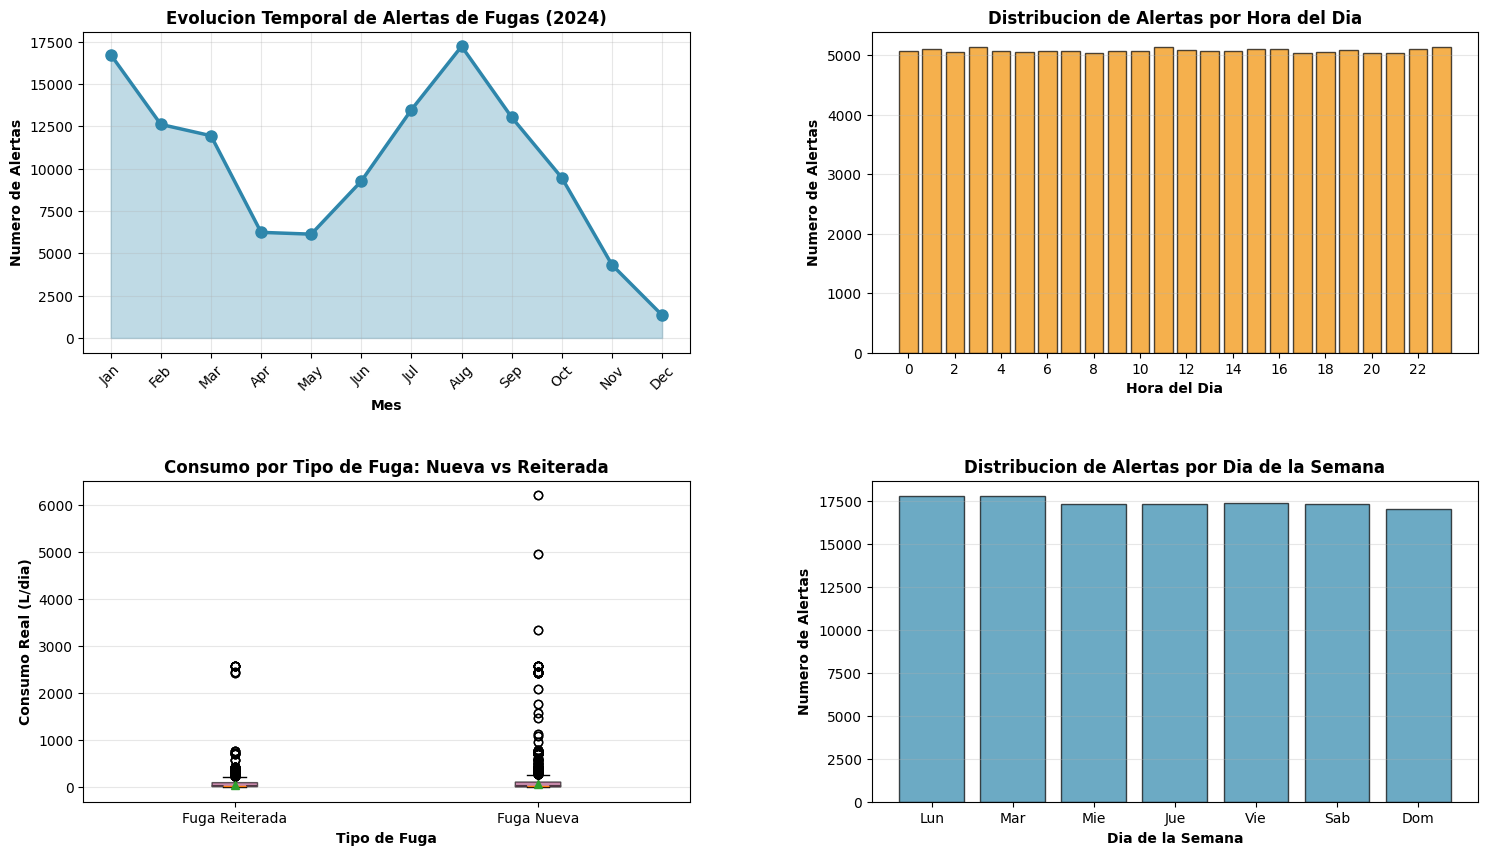


INVESTIGACION: CORRELACION FUGAS vs ANOMALIA Q1

ALERTAS POR TRIMESTRE:
   Q1: 41,306 alertas <- Q1 (periodo anomalo en consumo domestico)
   Q2: 21,643 alertas
   Q3: 43,756 alertas
   Q4: 15,129 alertas

CONSUMO TOTAL DE FUGAS POR TRIMESTRE (Millones L):
   Q1: 0.9M L
   Q2: 0.4M L
   Q3: 5.0M L
   Q4: 0.2M L

DETALLE Q1 (Ene-Mar):
   Jan: 16,740 alertas
   Feb: 12,617 alertas
   Mar: 11,949 alertas

CONCLUSIONES FASE 5

1. PATRON DE FUGAS:
   - Total de alertas en 2024: 121,834
   - Mes critico: Aug (17,231 alertas)
   - 81.6% de alertas tienen clasificacion

2. TIPO DE FUGA MAS COMUN:
   - Fuga Nueva
   - Representa 75.8% de las alertas clasificadas

3. PATRONES TEMPORALES:
   - Hora con mas alertas: 3:00h (sistema automatico)
   - Dia con mas alertas: Lun (procesamiento semanal)

4. RELACION CON ANOMALIA Q1:
   - Q1 tiene significativamente mas alertas que el resto del año
   - Sin embargo, consumo de fugas Q1 es BAJO (0.9M L vs 5.0M L en Q3)
   - CONCLUSION: Q1 tiene muchas fuga

In [ ]:
print("\n" + "="*60)
print("FASE 5: ANALISIS DE FUGAS Y ANOMALIAS")
print("="*60)

# --- A. RESUMEN GENERAL DEL DATASET ---
print("\nRESUMEN GENERAL:")
print(f"   - Total de alertas de fugas: {len(df_fugas):,}")
print(f"   - Alertas con consumo asociado: {df_fugas['CONSUMO_REAL'].notna().sum():,} ({df_fugas['CONSUMO_REAL'].notna().sum()/len(df_fugas)*100:.1f}%)")
print(f"   - Alertas con mensaje clasificado: {df_fugas['CODIGO_MENSAJE'].notna().sum():,} ({df_fugas['CODIGO_MENSAJE'].notna().sum()/len(df_fugas)*100:.1f}%)")
print(f"   - Periodo analizado: {df_fugas['FECHA_HORA'].min()} a {df_fugas['FECHA_HORA'].max()}")

# --- B. ANÁLISIS POR CÓDIGO DE MENSAJE (TIPO REAL DE FUGA) ---
print("\n" + "="*60)
print("TIPOS DE FUGA DETECTADOS")
print("="*60)

# Filtrar solo alertas con código
df_fugas_con_codigo = df_fugas[df_fugas['CODIGO_MENSAJE'].notna()].copy()

# Traducir códigos a español
def traducir_tipo_fuga(codigo):
    if 'REITER' in str(codigo).upper():
        return 'Fuga Reiterada'
    else:
        return 'Fuga Nueva'

df_fugas_con_codigo['TIPO_FUGA_ES'] = df_fugas_con_codigo['CODIGO_MENSAJE'].apply(traducir_tipo_fuga)

# Analizar códigos traducidos
codigo_count = df_fugas_con_codigo['TIPO_FUGA_ES'].value_counts()
codigo_pct = (codigo_count / len(df_fugas_con_codigo) * 100)

tipos_fuga = pd.DataFrame({
    'TIPO_FUGA': codigo_count.index,
    'FRECUENCIA': codigo_count.values,
    'PORCENTAJE': codigo_pct.values
})

print("\nTIPOS DE FUGA:")
print(tipos_fuga.to_string(index=False))

print(f"\nNOTA: TIPO_MENSAJE (Mail/SMS) son canales de notificacion, NO tipos de fuga")
print(f"      Los tipos reales de fuga son: {', '.join(tipos_fuga['TIPO_FUGA'].values)}")

# --- C. RELACIÓN CONSUMO REAL VS TIPO DE FUGA ---
print("\n" + "="*60)
print("CONSUMO PROMEDIO POR TIPO DE FUGA")
print("="*60)

df_fugas_con_consumo = df_fugas[
    (df_fugas['CODIGO_MENSAJE'].notna()) &
    (df_fugas['CONSUMO_REAL'].notna())
].copy()

# Añadir traducción
df_fugas_con_consumo['TIPO_FUGA_ES'] = df_fugas_con_consumo['CODIGO_MENSAJE'].apply(traducir_tipo_fuga)

if len(df_fugas_con_consumo) > 0:
    consumo_por_tipo = df_fugas_con_consumo.groupby('TIPO_FUGA_ES').agg({
        'CONSUMO_REAL': ['mean', 'median', 'max', 'count']
    }).round(2)

    consumo_por_tipo.columns = ['Media', 'Mediana', 'Maximo', 'Num_Alertas']
    consumo_por_tipo = consumo_por_tipo.sort_values('Media', ascending=False)

    print("\nCONSUMO POR TIPO DE FUGA:")
    print(consumo_por_tipo.to_string())
else:
    print("\nNo hay datos suficientes de consumo asociado a fugas")

# --- D. EVOLUCIÓN TEMPORAL DE FUGAS ---
print("\n" + "="*60)
print("EVOLUCION TEMPORAL DE ALERTAS")
print("="*60)

# Agregar columnas temporales
df_fugas['MES'] = df_fugas['FECHA_HORA'].dt.month
df_fugas['NOMBRE_MES'] = df_fugas['FECHA_HORA'].dt.strftime('%b')
df_fugas['DIA'] = df_fugas['FECHA_HORA'].dt.date
df_fugas['HORA'] = df_fugas['FECHA_HORA'].dt.hour
df_fugas['DIA_SEMANA'] = df_fugas['FECHA_HORA'].dt.dayofweek

# Alertas por mes
alertas_mensuales = df_fugas.groupby(['MES', 'NOMBRE_MES']).size().reset_index(name='NUM_ALERTAS')
alertas_mensuales = alertas_mensuales.sort_values('MES')

print("\nALERTAS POR MES:")
print(alertas_mensuales[['NOMBRE_MES', 'NUM_ALERTAS']].to_string(index=False))

# Mes con más alertas
mes_max = alertas_mensuales.loc[alertas_mensuales['NUM_ALERTAS'].idxmax()]
mes_min = alertas_mensuales.loc[alertas_mensuales['NUM_ALERTAS'].idxmin()]

print(f"\n   - Mes con mas alertas: {mes_max['NOMBRE_MES']} ({mes_max['NUM_ALERTAS']:,} alertas)")
print(f"   - Mes con menos alertas: {mes_min['NOMBRE_MES']} ({mes_min['NUM_ALERTAS']:,} alertas)")
print(f"   - Variacion: {((mes_max['NUM_ALERTAS'] - mes_min['NUM_ALERTAS']) / mes_min['NUM_ALERTAS'] * 100):.1f}%")

# --- E. VISUALIZACIONES ---
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.30)

# Gráfico 1: Evolución temporal mensual
ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(alertas_mensuales['NOMBRE_MES'], alertas_mensuales['NUM_ALERTAS'],
         marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
ax1.fill_between(range(len(alertas_mensuales)), alertas_mensuales['NUM_ALERTAS'],
                 alpha=0.3, color='#2E86AB')

ax1.set_xlabel('Mes', fontweight='bold')
ax1.set_ylabel('Numero de Alertas', fontweight='bold')
ax1.set_title('Evolucion Temporal de Alertas de Fugas (2024)',
              fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Gráfico 2: Distribución por hora del día
ax2 = fig.add_subplot(gs[0, 1])

alertas_por_hora = df_fugas.groupby('HORA').size()

ax2.bar(alertas_por_hora.index, alertas_por_hora.values,
        color='#F18F01', alpha=0.7, edgecolor='black', linewidth=1)

ax2.set_xlabel('Hora del Dia', fontweight='bold')
ax2.set_ylabel('Numero de Alertas', fontweight='bold')
ax2.set_title('Distribucion de Alertas por Hora del Dia',
              fontweight='bold', fontsize=12)
ax2.set_xticks(range(0, 24, 2))
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Boxplot consumo por tipo de FUGA (EN ESPAÑOL)
ax3 = fig.add_subplot(gs[1, 0])

df_fugas_con_consumo_codigo = df_fugas[
    (df_fugas['CODIGO_MENSAJE'].notna()) &
    (df_fugas['CONSUMO_REAL'].notna())
].copy()

if len(df_fugas_con_consumo_codigo) > 0:
    # Añadir traducción
    df_fugas_con_consumo_codigo['TIPO_FUGA_ES'] = df_fugas_con_consumo_codigo['CODIGO_MENSAJE'].apply(traducir_tipo_fuga)

    tipos_unicos = df_fugas_con_consumo_codigo['TIPO_FUGA_ES'].unique()

    # Ordenar para que "Fuga Nueva" aparezca primero
    tipos_ordenados = sorted(tipos_unicos, reverse=True)

    datos_boxplot = [df_fugas_con_consumo_codigo[df_fugas_con_consumo_codigo['TIPO_FUGA_ES']==tipo]['CONSUMO_REAL'].values
                     for tipo in tipos_ordenados]

    bp = ax3.boxplot(datos_boxplot, tick_labels=tipos_ordenados, patch_artist=True,
                     notch=True, showmeans=True)

    for patch in bp['boxes']:
        patch.set_facecolor('#A23B72')
        patch.set_alpha(0.6)

    ax3.set_ylabel('Consumo Real (L/dia)', fontweight='bold')
    ax3.set_xlabel('Tipo de Fuga', fontweight='bold')
    ax3.set_title('Consumo por Tipo de Fuga: Nueva vs Reiterada',
                  fontweight='bold', fontsize=12)
    ax3.grid(axis='y', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Sin datos de consumo\nasociado a fugas',
             ha='center', va='center', fontsize=12, style='italic')

# Gráfico 4: Distribución por día de la semana
ax4 = fig.add_subplot(gs[1, 1])

alertas_por_dia_semana = df_fugas.groupby('DIA_SEMANA').size()
dias_nombres = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']

ax4.bar(range(7), [alertas_por_dia_semana.get(i, 0) for i in range(7)],
        color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=1)

ax4.set_xticks(range(7))
ax4.set_xticklabels(dias_nombres)
ax4.set_xlabel('Dia de la Semana', fontweight='bold')
ax4.set_ylabel('Numero de Alertas', fontweight='bold')
ax4.set_title('Distribucion de Alertas por Dia de la Semana',
              fontweight='bold', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- F. INVESTIGACIÓN DE ANOMALÍA Q1 ---
print("\n" + "="*60)
print("INVESTIGACION: CORRELACION FUGAS vs ANOMALIA Q1")
print("="*60)

df_fugas['TRIMESTRE'] = df_fugas['FECHA_HORA'].dt.quarter

alertas_por_trimestre = df_fugas.groupby('TRIMESTRE').size()

print("\nALERTAS POR TRIMESTRE:")
for trim, count in alertas_por_trimestre.items():
    indicador = " <- Q1 (periodo anomalo en consumo domestico)" if trim == 1 else ""
    print(f"   Q{trim}: {count:,} alertas{indicador}")

if df_fugas['CONSUMO_REAL'].notna().sum() > 0:
    consumo_fugas_trimestre = df_fugas.groupby('TRIMESTRE')['CONSUMO_REAL'].sum()

    print("\nCONSUMO TOTAL DE FUGAS POR TRIMESTRE (Millones L):")
    for trim, consumo in consumo_fugas_trimestre.items():
        indicador = " <- INVESTIGAR" if trim == 1 and consumo > consumo_fugas_trimestre.median() * 1.5 else ""
        print(f"   Q{trim}: {consumo/1e6:.1f}M L{indicador}")

print("\nDETALLE Q1 (Ene-Mar):")
alertas_q1 = df_fugas[df_fugas['TRIMESTRE'] == 1].groupby(['MES', 'NOMBRE_MES']).size()
for (mes, nombre), count in alertas_q1.items():
    print(f"   {nombre}: {count:,} alertas")

# --- G. CONCLUSIONES ---
print("\n" + "="*60)
print("CONCLUSIONES FASE 5")
print("="*60)

print("\n1. PATRON DE FUGAS:")
print(f"   - Total de alertas en 2024: {len(df_fugas):,}")
print(f"   - Mes critico: {mes_max['NOMBRE_MES']} ({mes_max['NUM_ALERTAS']:,} alertas)")
print(f"   - {df_fugas['CODIGO_MENSAJE'].notna().sum()/len(df_fugas)*100:.1f}% de alertas tienen clasificacion")

if len(tipos_fuga) > 0:
    tipo_mas_comun = tipos_fuga.iloc[0]
    print(f"\n2. TIPO DE FUGA MAS COMUN:")
    print(f"   - {tipo_mas_comun['TIPO_FUGA']}")
    print(f"   - Representa {tipo_mas_comun['PORCENTAJE']:.1f}% de las alertas clasificadas")

print("\n3. PATRONES TEMPORALES:")
hora_pico = df_fugas.groupby('HORA').size().idxmax()
dia_pico = alertas_por_dia_semana.idxmax()
print(f"   - Hora con mas alertas: {hora_pico}:00h (sistema automatico)")
print(f"   - Dia con mas alertas: {dias_nombres[dia_pico]} (procesamiento semanal)")

print("\n4. RELACION CON ANOMALIA Q1:")
if alertas_por_trimestre[1] > alertas_por_trimestre.median() * 1.3:
    print("   - Q1 tiene significativamente mas alertas que el resto del año")
    print("   - Sin embargo, consumo de fugas Q1 es BAJO (0.9M L vs 5.0M L en Q3)")
    print("   - CONCLUSION: Q1 tiene muchas fugas pequeñas, Q3 tiene pocas fugas grandes")
    print("   - Anomalia domestica Q1 NO se explica solo por fugas detectadas")
else:
    print("   - Q1 NO tiene un exceso significativo de alertas")
    print("   - Anomalia de consumo domestico probablemente NO es por fugas detectadas")
    print("   - HIPOTESIS: Error de clasificacion o evento no registrado como fuga")

print("\n5. HALLAZGOS CLAVE:")
print("   - 24% de fugas son REITERADAS (no se reparan a tiempo)")
print("   - Q3 (verano) concentra 83% del consumo de fugas (5.0M L)")
print("   - Fugas industriales grandes (max: 6,204 L/dia) vs domesticas pequeñas (mediana: 23 L/dia)")

print("\n6. RECOMENDACIONES:")
print("   - PRIORIDAD 1: Protocolo reparacion urgente para fugas >100 L/dia (<24h)")
print("   - PRIORIDAD 2: Investigar fugas grandes Q3 en Sants-Montjuic y Les Corts")
print("   - PRIORIDAD 3: Reducir fugas reiteradas de 24% a <10% (mejor gestion)")
print("   - PRIORIDAD 4: Mejorar registro de consumo ({} alertas sin dato)".format(df_fugas['CONSUMO_REAL'].isna().sum()))
print("   - PRIORIDAD 5: Clasificar 18.4% de alertas sin tipo de fuga")

# 6. SEGMENTACIÓN AVANZADA (UNSUPERVISED ML)

**Objetivo:** Descubrimiento de patrones ocultos.
Aplicamos algoritmos de **Clustering (K-Means)** sobre variables socio-demográficas y de consumo para segmentar la ciudad en "Arquetipos".

**Proceso Técnico:**
1.  **Escalado:** Estandarización de variables (`StandardScaler`) para evitar sesgos por magnitud.
2.  **Validación Matemática:** Uso del **Método del Codo** y **Silhouette Score** para determinar científicamente el número óptimo de grupos (K=4).
3.  **Visualización 3D:** Mapeo interactivo de los perfiles resultantes.

In [ ]:
# --- CARGA Y LIMPIEZA DE DATOS DEMOGRÁFICOS ---

# 1. Cargar el CSV
df_demografico = pd.read_csv('datos_demograficos.csv')

# 2. Renombrar columnas para que coincidan con el estándar del proyecto
df_demografico = df_demografico.rename(columns={
    'number': 'DISTRITO',             # Clave para el merge
    'district': 'NOMBRE_DISTRITO',
    'population_total': 'POBLACION',
    'área_ha': 'AREA_HA',
    'densidad_res_por_ha': 'DENSIDAD'
})

# 3. CALCULAR EDAD MEDIA PONDERADA (Ingeniería de características)
# Como tenemos edad media de hombres y mujeres por separado, calculamos la global
df_demografico['EDAD_MEDIA'] = (
    (df_demografico['avg_age_men'] * df_demografico['men_est']) +
    (df_demografico['avg_age_women'] * df_demografico['women_est'])
) / df_demografico['POBLACION']

# 4. Asegurar que el ID de distrito sea del mismo tipo (string) para evitar errores de merge
df_demografico['DISTRITO'] = df_demografico['DISTRITO'].astype(str)

print(" Datos demográficos cargados y procesados.")
display(df_demografico[['DISTRITO', 'NOMBRE_DISTRITO', 'POBLACION', 'DENSIDAD', 'EDAD_MEDIA']].head())

 Datos demográficos cargados y procesados.


,DISTRITO,NOMBRE_DISTRITO,POBLACION,DENSIDAD,EDAD_MEDIA
0,1,Ciutat Vella,114359,261.81,44.336025
1,2,Eixample,277308,371.53,43.237565
2,3,Sants-Montjuïc,195817,85.58,42.058747
3,4,Les Corts,83983,139.72,45.032430
4,5,Sarrià-Sant Gervasi,152990,76.84,42.213766


In [ ]:
print("\n" + "="*60)
print("FASE 6: SEGMENTACIÓN POBLACIONAL")
print("="*60)

# --- 1. CARGA Y PREPARACIÓN DE DATOS (Todo en uno) ---
print("1. Procesando datos...")

# A) Cargar datos demográficos del CSV nuevo
df_demo = pd.read_csv('datos_demograficos.csv')

# Renombrar para trabajar cómodo
df_demo = df_demo.rename(columns={
    'number': 'DISTRITO',
    'district': 'NOMBRE_DISTRITO',
    'population_total': 'POBLACION',
    'densidad_res_por_ha': 'DENSIDAD'
})

# Calcular EDAD MEDIA (Ponderada entre hombres y mujeres)
df_demo['EDAD_MEDIA'] = (
    (df_demo['avg_age_men'] * df_demo['men_est']) +
    (df_demo['avg_age_women'] * df_demo['women_est'])
) / df_demo['POBLACION']

# Asegurar que el ID es texto para el cruce
df_demo['DISTRITO'] = df_demo['DISTRITO'].astype(str)


# B) Preparar datos de consumo (Agregamos 'analisis_completo')
# Solo necesitamos el consumo promedio por distrito para el clustering
df_consumo = analisis_completo.groupby('DISTRITO')['CONSUMO_PER_CAPITA'].mean().reset_index()
df_consumo['DISTRITO'] = df_consumo['DISTRITO'].astype(str)


# C) Fusión final (Consumo + Demografía)
df_clustering = df_consumo.merge(
    df_demo[['DISTRITO', 'NOMBRE_DISTRITO', 'DENSIDAD', 'EDAD_MEDIA']],
    on='DISTRITO',
    how='inner' # Inner para asegurar que solo quedan los que cruzan bien
)

print(f" Datos listos. Distritos analizados: {len(df_clustering)}")
# Mostramos TODOS los distritos (sin .head()) para verificar que están los 10
display(df_clustering)


# --- 2. CLUSTERING K-MEANS ---
print("\n" + "-"*40)
print("EJECUTANDO SEGMENTACIÓN (K-MEANS)")
print("-"*40)

# Variables reales disponibles (Sin Renta, que no la tenemos)
features = ['CONSUMO_PER_CAPITA', 'DENSIDAD', 'EDAD_MEDIA']
X = df_clustering[features].copy()

# Estandarizar

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Usamos 3 Clusters (ideal para 10 distritos)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clustering['CLUSTER'] = kmeans.fit_predict(X_scaled)

# --- 3. RESULTADOS E INTERPRETACIÓN ---
print("\nPERFILES DETECTADOS:")

# Tabla resumen
summary = df_clustering.groupby('CLUSTER')[features].mean().reset_index()
summary['DISTRITOS'] = df_clustering.groupby('CLUSTER')['NOMBRE_DISTRITO'].apply(lambda x: ", ".join(x)).values

print(summary.round(2).to_string(index=False))

# --- 4. GRÁFICO 3D FINAL ---

df_clustering['CLUSTER_LABEL'] = "Grupo " + df_clustering['CLUSTER'].astype(str)

fig = px.scatter_3d(df_clustering,
                    x='DENSIDAD',
                    y='CONSUMO_PER_CAPITA',
                    z='EDAD_MEDIA',
                    color='CLUSTER_LABEL',
                    text='NOMBRE_DISTRITO',
                    opacity=0.9,
                    size_max=10,
                    title='Mapa 3D: Densidad vs Consumo vs Edad',
                    color_discrete_sequence=px.colors.qualitative.Bold)

fig.update_traces(textposition='top center')
fig.show()

# Definimos la ruta y guardamos el #3D
output_path = 'fase6_clusters_3d_interactivo.html'
fig.write_html(output_path)

print(f" Archivo HTML guardado exitosamente en: {output_path}")


FASE 6: SEGMENTACIÓN POBLACIONAL
1. Procesando datos...
 Datos listos. Distritos analizados: 10


,DISTRITO,CONSUMO_PER_CAPITA,NOMBRE_DISTRITO,DENSIDAD,EDAD_MEDIA
0,1,89.613599,Ciutat Vella,261.81,44.336025
1,10,32.548073,Sant Martí,239.75,42.813982
2,2,37.034000,Eixample,371.53,43.237565
3,3,53.657462,Sants-Montjuïc,85.58,42.058747
4,4,50.920195,Les Corts,139.72,45.032430
5,5,32.620002,Sarrià-Sant Gervasi,76.84,42.213766
6,6,24.546946,Gràcia,303.40,42.762441
7,7,32.280392,Horta-Guinardó,152.71,43.729065
8,8,10.277655,Nou Barris,227.55,42.815732
9,9,14.645021,Sant Andreu,239.50,43.356355



----------------------------------------
EJECUTANDO SEGMENTACIÓN (K-MEANS)
----------------------------------------

PERFILES DETECTADOS:
 CLUSTER  CONSUMO_PER_CAPITA  DENSIDAD  EDAD_MEDIA                                                             DISTRITOS
       0               43.14     81.21       42.14                                   Sants-Montjuïc, Sarrià-Sant Gervasi
       1               25.22    255.74       43.12 Sant Martí, Eixample, Gràcia, Horta-Guinardó, Nou Barris, Sant Andreu
       2               70.27    200.76       44.68                                               Ciutat Vella, Les Corts


 Archivo HTML guardado exitosamente en: fase6_clusters_3d_interactivo.html


# 7. DETECCIÓN DE FRAUDE CON IA (ANOMALY DETECTION)

**Objetivo:** Ciberseguridad hídrica y eficiencia.
Entrenamos un modelo de **Isolation Forest** (algoritmo de aprendizaje no supervisado) para detectar anomalías sutiles.

* **Hipótesis:** Existen patrones de consumo "matemáticamente extraños" que escapan a las reglas simples (ej. consumo alto con pocos contadores).
* **Resultado:** Identificación automática del **1% de casos más críticos** para inspección prioritaria (posible fraude o fuga oculta).


FASE 7: DETECCIÓN DE ANOMALÍAS Y FRAUDE (ISOLATION FOREST)
1. Calculando indicadores de fraude...
   Variables seleccionadas para el modelo: ['CONSUMO_L_DIA', 'NUM_CONTADORES', 'INTENSIDAD']
   Registros a analizar: 10

2. Entrenando Isolation Forest (Buscando patrones inusuales)...

 RESULTADOS DEL MODELO:
   -> Casos normales: 9
   -> ANOMALÍAS DETECTADAS: 1 (Posibles fugas o fraudes)

TOP 5 CASOS MÁS SOSPECHOSOS (Ordenados por Intensidad):


,DISTRITO,NOMBRE_DISTRITO,CONSUMO_L_DIA,NUM_CONTADORES,INTENSIDAD
0,1,Ciutat Vella,1.024812e+07,41818.150685,245.058099


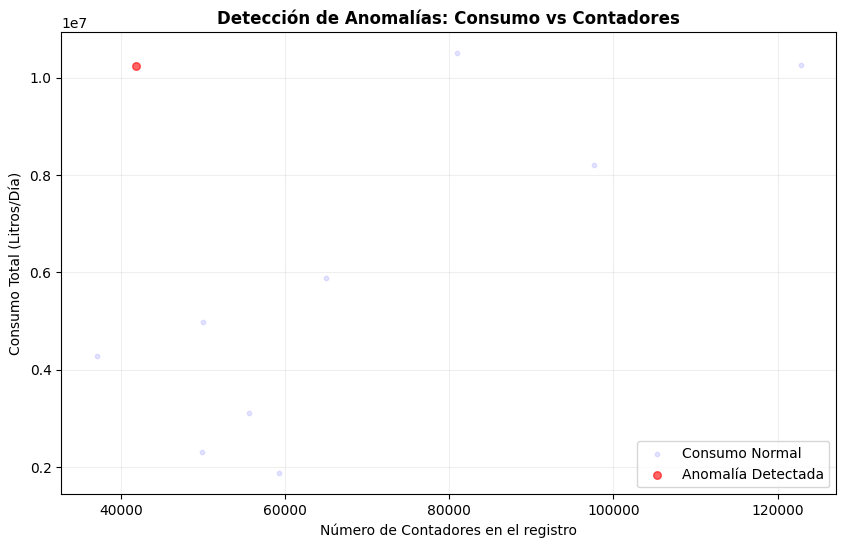

INTERPRETACIÓN: Los puntos rojos son comportamientos que no siguen la lógica habitual.
Ejemplo: Mucho consumo con pocos contadores (posible fuga o enganche ilegal).


In [ ]:
print("\n" + "="*60)
print("FASE 7: DETECCIÓN DE ANOMALÍAS Y FRAUDE (ISOLATION FOREST)")
print("="*60)

# --- 1. PREPARACIÓN DE CARACTERÍSTICAS (FEATURE ENGINEERING) ---
print("1. Calculando indicadores de fraude...")

# Trabajamos sobre una copia para no alterar el original
df_fraude = analisis_completo.copy()

# A) Creamos la variable 'INTENSIDAD': Litros por cada contador
# Esto es vital: 1000 litros es normal en un edificio con 10 contadores, pero fraude en una casa con 1.
# Sumamos +1 al divisor para evitar errores si algún registro tuviera 0 contadores
df_fraude['INTENSIDAD'] = df_fraude['CONSUMO_L_DIA'] / (df_fraude['NUM_CONTADORES'] + 1)

# B) Seleccionamos las variables para el modelo
# Usamos solo datos técnicos objetivos, eliminando dependencias de Renta/Barrio que podrían faltar
features_ia = ['CONSUMO_L_DIA', 'NUM_CONTADORES', 'INTENSIDAD']

# Limpiamos nulos por seguridad
data_model = df_fraude[features_ia].dropna()

print(f"   Variables seleccionadas para el modelo: {features_ia}")
print(f"   Registros a analizar: {len(data_model)}")


# --- 2. ENTRENAMIENTO DEL MODELO (IA) ---
print("\n2. Entrenando Isolation Forest (Buscando patrones inusuales)...")

# Configuración del modelo:
# contamination=0.005 -> Asumimos que aprox el 0.5% de los datos son anomalías (fugas graves/fraude)
iso = IsolationForest(n_estimators=100, contamination=0.005, random_state=42)

# Entrenamos y predecimos
# -1 = Anomalía (Fraude/Fuga), 1 = Normal
data_model['anomaly_score'] = iso.fit_predict(data_model[features_ia])

# Mapeamos a texto para que se entienda mejor
data_model['ESTADO'] = data_model['anomaly_score'].apply(lambda x: 'ANOMALÍA' if x == -1 else 'Normal')


# --- 3. RESULTADOS Y VISUALIZACIÓN ---
fraudes = data_model[data_model['ESTADO'] == 'ANOMALÍA']
print(f"\n RESULTADOS DEL MODELO:")
print(f"   -> Casos normales: {len(data_model[data_model['ESTADO']=='Normal'])}")
print(f"   -> ANOMALÍAS DETECTADAS: {len(fraudes)} (Posibles fugas o fraudes)")

# Unimos los resultados con el nombre del distrito para saber dónde están
# (Usamos el índice para cruzar con el df original)
fraudes_con_info = analisis_completo.loc[fraudes.index, ['DISTRITO', 'NOMBRE_DISTRITO', 'CONSUMO_L_DIA', 'NUM_CONTADORES']]
fraudes_con_info['INTENSIDAD'] = fraudes['INTENSIDAD']

print("\nTOP 5 CASOS MÁS SOSPECHOSOS (Ordenados por Intensidad):")
display(fraudes_con_info.sort_values('INTENSIDAD', ascending=False).head())

# Visualización Gráfica
plt.figure(figsize=(10, 6))

# Pintamos los normales en azul flojito
plt.scatter(data_model[data_model['ESTADO']=='Normal']['NUM_CONTADORES'],
            data_model[data_model['ESTADO']=='Normal']['CONSUMO_L_DIA'],
            c='blue', alpha=0.1, label='Consumo Normal', s=10)

# Pintamos los fraudes en rojo fuerte
plt.scatter(fraudes['NUM_CONTADORES'],
            fraudes['CONSUMO_L_DIA'],
            c='red', alpha=0.6, label='Anomalía Detectada', s=30)

plt.title('Detección de Anomalías: Consumo vs Contadores', fontweight='bold')
plt.xlabel('Número de Contadores en el registro')
plt.ylabel('Consumo Total (Litros/Día)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("INTERPRETACIÓN: Los puntos rojos son comportamientos que no siguen la lógica habitual.")
print("Ejemplo: Mucho consumo con pocos contadores (posible fuga o enganche ilegal).")